# Deep Metric Learning for Image Retrieval
### 工业级 Pipeline：从 Triplet Loss 到 LoRA 微调

| 章节 | 内容 |
|------|------|
| 0 | 环境安装 & 配置 |
| 1 | 数据流水线（Data Pipeline） |
| 2 | 模型架构：ResNet152 / LoRA 原理 / CLIP+LoRA |
| 3 | 损失函数：Triplet Loss + Batch Hard Mining |
| 4 | 训练器：AMP + Gradient Checkpointing + Gradient Accumulation |
| 5 | 评估体系：AUC / MAP@K / NDCG / t-SNE |
| 6 | FAISS 检索加速 |
| 7 | 实验对比：Baseline vs Fine-tune vs CLIP+LoRA |
| 8 | Test Set Inference & Submission |
| 9 | 重复实验：Multi-seed / Multi-split Robustness |
| 10 | 消融实验：Mining / LoRA / Embedding Dim |
| 11 | 失败案例分析：Rank、误检与可视化 |


## Section 0 — 环境安装 & 配置

In [6]:
# ── AutoDL 服务器首次运行：取消注释安装 ──────────────────────────────────────
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
# !pip install transformers peft accelerate
# !pip install scikit-learn matplotlib seaborn opencv-python-headless Pillow tqdm
# !pip install wandb

# FAISS：RTX 4090 使用 CUDA 12，必须装 cu12 版本，旧版 faiss-gpu 仅支持 CUDA 11
# !pip install faiss-gpu-cu12
# 备选（更稳定，推荐 conda 环境）：
# !conda install -c pytorch -c nvidia faiss-gpu=1.8.0 -y

In [1]:
import os, sys, math, time, random, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional
from copy import deepcopy

# ── AutoDL：HuggingFace 镜像（必须在 import transformers 之前设置）────────────
# CLIP 模型约 600MB，不设镜像在国内服务器会超时
os.environ.setdefault("HF_ENDPOINT", "https://hf-mirror.com")
os.environ.setdefault("HF_HOME", "/root/autodl-tmp/.cache/huggingface")  # 存到持久盘
os.environ.setdefault("TORCH_HOME", "/root/autodl-tmp/.cache/torch")      # ResNet152 等权重缓存到数据盘
os.environ.setdefault("WANDB_MODE", "offline")                             # 离线存储，跑完 wandb sync 上传

import wandb

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models

# AMP (混合精度)
from torch.amp import autocast, GradScaler

# ── Optional dependencies ─────────────────────────────────────────────────────
try:
    import faiss
    FAISS_AVAILABLE = True
    print("✓ FAISS available")
except ImportError:
    FAISS_AVAILABLE = False
    print("✗ FAISS not found — RTX 4090 请用: pip install faiss-gpu-cu12")

try:
    from transformers import CLIPModel, CLIPProcessor
    from peft import LoraConfig, get_peft_model
    CLIP_AVAILABLE = True
    print("✓ Transformers + PEFT available")
except ImportError:
    CLIP_AVAILABLE = False
    print("✗ Transformers/PEFT not found — run: pip install transformers peft")

warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

✗ FAISS not found — RTX 4090 请用: pip install faiss-gpu-cu12
✓ Transformers + PEFT available

Device: cuda
GPU   : NVIDIA GeForce RTX 4090
VRAM  : 23.5 GB


In [2]:
@dataclass
class Config:
    # ── Paths（AutoDL：改成持久盘路径）────────────────────────────────────────
    data_root: str = "/root/autodl-tmp/tll-metric-learning/data"  # 数据存到数据盘
    save_dir:  str = "/root/autodl-tmp/tll-metric-learning/checkpoints"  # 存到数据盘，避免 30G 系统盘打满

    # ── Data ───────────────────────────────────────────────────────────────────
    img_size:    int   = 224
    batch_size:  int   = 64    # RTX 4090 24GB：ResNet152 跑 64 约占 8GB，还有很多余量
    num_workers: int   = 8     # AutoDL 实例通常 16 核，用 8 个 worker 加速数据读取
    val_split:   float = 0.15
    seed:        int   = 42
    split_seed:  int   = 42

    # ── Model ──────────────────────────────────────────────────────────────────
    backbone:      str  = "resnet152"  # "resnet152" | "clip"
    embedding_dim: int  = 256
    pretrained:    bool = True

    # ── LoRA（backbone="clip" 时生效）──────────────────────────────────────────
    use_lora:             bool      = True
    lora_r:               int       = 8
    lora_alpha:           int       = 16
    lora_dropout:         float     = 0.1
    lora_target_modules:  List[str] = field(
        default_factory=lambda: ["q_proj", "v_proj"]
    )

    # ── Training ───────────────────────────────────────────────────────────────
    epochs:                   int   = 20
    lr:                       float = 1e-4
    weight_decay:             float = 1e-4
    warmup_epochs:            int   = 2
    early_stopping_patience:  int   = 5

    # ── Loss ───────────────────────────────────────────────────────────────────
    triplet_margin:  float = 0.1
    distance_metric: str   = "cosine"
    mining:          str   = "batch_hard"

    # ── 显存优化（4090 24GB 很宽裕，grad_checkpoint 关掉省时间）──────────────
    use_amp:                  bool = True
    use_grad_checkpoint:      bool = False
    grad_accumulation_steps:  int  = 1

    # ── FAISS ──────────────────────────────────────────────────────────────────
    faiss_nlist:  int = 100
    faiss_nprobe: int = 10

    # ── Evaluation ─────────────────────────────────────────────────────────────
    eval_k_values: List[int] = field(default_factory=lambda: [1, 5, 10])

    # ── Test ───────────────────────────────────────────────────────────────────
    test_split:    str = "test 2"           # 测试集子目录名
    test_csv:      str = "test_candidates 2.csv"


cfg = Config()
os.makedirs(cfg.save_dir, exist_ok=True)
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
random.seed(cfg.seed)
print(cfg)

Config(data_root='/root/autodl-tmp/tll-metric-learning/data', save_dir='/root/autodl-tmp/tll-metric-learning/checkpoints', img_size=224, batch_size=64, num_workers=8, val_split=0.15, seed=42, split_seed=42, backbone='resnet152', embedding_dim=256, pretrained=True, use_lora=True, lora_r=8, lora_alpha=16, lora_dropout=0.1, lora_target_modules=['q_proj', 'v_proj'], epochs=20, lr=0.0001, weight_decay=0.0001, warmup_epochs=2, early_stopping_patience=5, triplet_margin=0.1, distance_metric='cosine', mining='batch_hard', use_amp=True, use_grad_checkpoint=False, grad_accumulation_steps=1, faiss_nlist=100, faiss_nprobe=10, eval_k_values=[1, 5, 10], test_split='test 2', test_csv='test_candidates 2.csv')


## Section 1 — 数据流水线

**任务结构**：给定 2000 个 query 图像，每个 query 有一个 positive（ground truth match）。Negative 从其他对中随机采样。

**为什么用 Triplet 而不是分类 Loss？**  
图像检索本质上是度量空间学习问题：我们希望「同类」的嵌入向量靠近，「异类」的远离，而不是区分固定类别。Triplet Loss 直接优化嵌入空间的相对距离，泛化性更好。

In [3]:
def pad_to_square(img: np.ndarray, fill: int = 255) -> np.ndarray:
    h, w = img.shape[:2]
    diff = abs(h - w)
    p1, p2 = diff // 2, diff - diff // 2
    pad = ((0, 0), (p1, p2), (0, 0)) if h > w else ((p1, p2), (0, 0), (0, 0))
    return np.pad(img, pad, constant_values=fill)


def load_image(name: str, side: str, data_root: str, split: str = "train") -> Image.Image:
    """通用图像加载，split 控制读取 train/ 还是 test 2/ 等子目录。"""
    path = os.path.join(data_root, split, side, f"{name}.jpg")
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    img = pad_to_square(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return Image.fromarray(img)


class TripletDataset(Dataset):
    """
    返回 (anchor, positive, negative) 三元组。

    负样本修正：从 left 和 right 两侧随机采样，避免模型学到域偏差
    （原实现只从 left 侧取负样本，会引入 left-vs-right 的域偏置）。
    """

    def __init__(self, df: pd.DataFrame, data_root: str, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_root = data_root
        self.transform = transform
        self.n = len(df)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        anchor   = load_image(row['left'],  'left',  self.data_root)
        positive = load_image(row['right'], 'right', self.data_root)

        neg_idx  = (idx + random.randint(1, self.n - 1)) % self.n
        neg_side = random.choice(['left', 'right'])  # 两侧混合，消除域偏差
        negative = load_image(self.df.iloc[neg_idx][neg_side], neg_side, self.data_root)

        if self.transform:
            anchor   = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative


class EmbeddingDataset(Dataset):
    """扁平化 Dataset，用于提取 embedding。支持 train / test 两个 split。"""

    def __init__(self, image_list: List[Tuple[str, str]], data_root: str,
                 transform=None, split: str = "train"):
        self.images    = image_list  # [(name, side), ...]
        self.data_root = data_root
        self.transform = transform
        self.split     = split

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        name, side = self.images[idx]
        img = load_image(name, side, self.data_root, split=self.split)
        if self.transform:
            img = self.transform(img)
        return img

In [4]:
# ── Transforms ────────────────────────────────────────────────────────────────
# 训练集：加数据增强（随机翻转 + 颜色抖动）增强泛化
# 验证/测试集：只做中心裁剪 + 归一化

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((cfg.img_size, cfg.img_size)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize((cfg.img_size, cfg.img_size)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Load CSV & Split ───────────────────────────────────────────────────────────
df_all = pd.read_csv(os.path.join(cfg.data_root, "train.csv"))
df_all = df_all.sample(frac=1, random_state=cfg.seed).reset_index(drop=True)  # 固定 seed 洗牌，消除顺序偏差
print(f"Total pairs: {len(df_all)}")

n_val = int(len(df_all) * cfg.val_split)
n_train = len(df_all) - n_val
df_train = df_all.iloc[:n_train].reset_index(drop=True)
df_val   = df_all.iloc[n_train:].reset_index(drop=True)

print(f"Train: {len(df_train)} pairs | Val: {len(df_val)} pairs")

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_ds = TripletDataset(df_train, cfg.data_root, train_transform)
val_ds   = TripletDataset(df_val,   cfg.data_root, val_transform)

train_loader = DataLoader(
    train_ds, batch_size=cfg.batch_size, shuffle=True,
    num_workers=cfg.num_workers, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=True
)

# Embedding DataLoader（用于评估）
anchor_images   = [(r['left'],  'left')  for _, r in df_val.iterrows()]
positive_images = [(r['right'], 'right') for _, r in df_val.iterrows()]

anchor_loader   = DataLoader(EmbeddingDataset(anchor_images,   cfg.data_root, val_transform),
                              batch_size=64, num_workers=cfg.num_workers, pin_memory=True)
positive_loader = DataLoader(EmbeddingDataset(positive_images, cfg.data_root, val_transform),
                              batch_size=64, num_workers=cfg.num_workers, pin_memory=True)

print(f"\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Total pairs: 2000
Train: 1700 pairs | Val: 300 pairs

Train batches: 27 | Val batches: 5


## Section 2 — 模型架构

### 2a. ResNet152 Embedding Network

**设计思路：**  
去掉 ResNet152 的分类头（fc layer），加一个两层 Projection Head，把 2048 维特征映射到更低维的 embedding 空间（256 维）。  
**为什么加 Projection Head？**  原始 2048 维空间由 ImageNet 分类任务优化，对检索任务不是最优。低维的归一化 embedding 更有利于 cosine similarity 计算，同时降低 FAISS 索引的存储和搜索成本。

In [5]:
class ResNetEmbedder(nn.Module):
    """
    ResNet152 骨干 + 两层 Projection Head。

    输出 L2 归一化的 embedding，方便直接用内积计算 cosine similarity。
    """

    def __init__(self, embedding_dim: int = 256, pretrained: bool = True,
                 use_grad_checkpoint: bool = False):
        super().__init__()
        self.use_grad_checkpoint = use_grad_checkpoint

        weights = models.ResNet152_Weights.IMAGENET1K_V2 if pretrained else None
        backbone = models.resnet152(weights=weights)
        feat_dim = backbone.fc.in_features  # 2048

        # 移除分类头，保留特征提取部分
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])  # → (B, 2048, 1, 1)

        # Projection Head: 2048 → 512 → embedding_dim
        self.projector = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(512, embedding_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.use_grad_checkpoint:
            # 只对 layer1-4（indices 4-7）做 block 级 checkpoint，不影响 Conv/BN/Pool
            # checkpoint_sequential 以每个 Bottleneck block 为单位重算，节省约 40% 显存
            for i, layer in enumerate(self.backbone):
                if i in (4, 5, 6, 7):
                    x = torch.utils.checkpoint.checkpoint_sequential(
                        layer, len(layer), x, use_reentrant=False
                    )
                else:
                    x = layer(x)
        else:
            x = self.backbone(x)
        feat = x.flatten(1)        # (B, 2048)
        emb  = self.projector(feat) # (B, embedding_dim)
        return F.normalize(emb, p=2, dim=1)


def count_params(model: nn.Module) -> str:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return f"Total: {total/1e6:.1f}M | Trainable: {trainable/1e6:.1f}M ({100*trainable/total:.1f}%)"


# 快速验证模型结构
demo = ResNetEmbedder(cfg.embedding_dim, pretrained=False).to(device)
x = torch.randn(2, 3, cfg.img_size, cfg.img_size, device=device)
out = demo(x)
print(f"Output shape: {out.shape}  | L2 norms: {out.norm(dim=1).tolist()}")  # 应该都是 1.0
print(f"Params — {count_params(demo)}")
del demo, x, out

Output shape: torch.Size([2, 256])  | L2 norms: [1.0, 1.0]
Params — Total: 59.3M | Trainable: 59.3M (100.0%)


### 2b. LoRA（Low-Rank Adaptation）从零实现

**核心思想（低秩假设）：**  
微调时权重的更新量 $\Delta W$ 往往是低秩的，即可以分解为两个小矩阵之积：
$$\Delta W = BA, \quad B \in \mathbb{R}^{d \times r},\ A \in \mathbb{R}^{r \times k},\ r \ll \min(d, k)$$

前向传播变为：$h = Wx + \Delta Wx = Wx + BAx \cdot \frac{\alpha}{r}$

**参数量对比（以 CLIP ViT-B/32 为例，d=k=768，r=8）：**  
- 全量微调一层：$768 \times 768 = 589{,}824$ 参数  
- LoRA 一层：$8 \times 768 + 768 \times 8 = 12{,}288$ 参数（**减少 98%**）

**初始化：** B 初始化为 0，A 初始化为高斯分布 → 训练开始时 $\Delta W = 0$，等同于从预训练起点出发。

In [6]:
class LoRALayer(nn.Module):
    """
    LoRA 低秩适配层。

    只学习 lora_A 和 lora_B，原始权重 W 始终冻结。
    缩放系数 alpha/r：r 增大时保持有效学习率不变。
    """

    def __init__(self, in_features: int, out_features: int,
                 r: int = 8, alpha: int = 16, dropout: float = 0.0):
        super().__init__()
        self.r       = r
        self.scaling = alpha / r

        # A：高斯初始化；B：全零初始化（确保训练起点 ΔW=0）
        self.lora_A = nn.Parameter(torch.empty(r, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, r))
        self.drop   = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ΔW·x = B·A·x，缩放后加回原输出
        return (self.drop(x) @ self.lora_A.T @ self.lora_B.T) * self.scaling


class LoRALinear(nn.Module):
    """nn.Linear 的 LoRA drop-in 替换。冻结原始权重，只训练低秩矩阵。"""

    def __init__(self, linear: nn.Linear, r: int = 8, alpha: int = 16, dropout: float = 0.0):
        super().__init__()
        self.linear = linear
        self.linear.weight.requires_grad_(False)   # 冻结原始权重
        if self.linear.bias is not None:
            self.linear.bias.requires_grad_(False)

        self.lora = LoRALayer(linear.in_features, linear.out_features, r, alpha, dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x) + self.lora(x)   # W·x + B·A·x·(α/r)


def inject_lora(model: nn.Module, target_names: List[str],
                r: int = 8, alpha: int = 16, dropout: float = 0.1) -> nn.Module:
    """
    将目标层替换为 LoRALinear。

    步骤：
    1. 冻结所有参数
    2. 找到名字匹配 target_names 的 Linear 层
    3. 替换为 LoRALinear（只有低秩矩阵可训练）
    """
    for param in model.parameters():
        param.requires_grad_(False)

    replaced = 0
    for name, module in list(model.named_modules()):
        if not any(name.endswith(t) for t in target_names):
            continue
        if not isinstance(module, nn.Linear):
            continue

        # 找到父模块，替换该属性
        parts = name.split('.')
        parent = model
        for part in parts[:-1]:
            parent = getattr(parent, part)
        setattr(parent, parts[-1], LoRALinear(module, r, alpha, dropout))
        replaced += 1

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"LoRA injected into {replaced} layers")
    print(f"Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")
    return model


# ── 演示参数量 ────────────────────────────────────────────────────────────────
d = 768  # CLIP ViT-B/32 hidden dim
r = cfg.lora_r
n_lora_layers = 12 * 2  # 12 transformer blocks × 2 (Q, V)
full_params  = d * d * n_lora_layers
lora_params  = (r * d + d * r) * n_lora_layers
print(f"CLIP ViT-B/32 全量微调目标层: {full_params/1e6:.2f}M 参数")
print(f"LoRA r={r} 替换后:            {lora_params/1e6:.3f}M 参数 (减少 {(1-lora_params/full_params)*100:.1f}%)")

CLIP ViT-B/32 全量微调目标层: 14.16M 参数
LoRA r=8 替换后:            0.295M 参数 (减少 97.9%)


### 2c. CLIP + LoRA 图像嵌入模型

**为什么用 CLIP？**  
CLIP 在 4 亿图文对上预训练，视觉编码器学到的语义表示比 ImageNet 分类监督更丰富，在跨域图像检索上表现更强。

**方案：LoRA 微调 + 自定义 PEFT（两种实现对比）**

In [7]:
class CLIPLoRAEmbedder(nn.Module):
    """
    CLIP ViT 视觉编码器 + LoRA 微调 + Projection Head。

    两种 LoRA 接入方式：
    1. use_peft=True  : 使用 HuggingFace PEFT 库（生产推荐）
    2. use_peft=False : 使用本 notebook 手写的 inject_lora（理解原理推荐）
    """

    def __init__(self, embedding_dim: int = 256, r: int = 8, alpha: int = 16,
                 dropout: float = 0.1, target_modules: List[str] = None,
                 use_peft: bool = False):
        super().__init__()

        if not CLIP_AVAILABLE:
            raise RuntimeError("请先安装: pip install transformers peft")

        clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.vision_encoder = clip.vision_model
        visual_dim = 768  # ViT-B/32 hidden dim

        if target_modules is None:
            target_modules = ["q_proj", "v_proj"]

        if use_peft:
            # ── 方案 1：PEFT 库（一行搞定）────────────────────────────────────
            lora_cfg = LoraConfig(
                r=r, lora_alpha=alpha, lora_dropout=dropout,
                target_modules=target_modules,
                bias="none",
            )
            self.vision_encoder = get_peft_model(self.vision_encoder, lora_cfg)
            self.vision_encoder.print_trainable_parameters()
        else:
            # ── 方案 2：手写 inject_lora（本 notebook 实现）──────────────────
            inject_lora(self.vision_encoder, target_modules, r, alpha, dropout)

        # Projection Head：[CLS] token (768) → embedding_dim（与 ResNetEmbedder 对齐，加 BN 稳定训练）
        self.projector = nn.Sequential(
            nn.Linear(visual_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, embedding_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # CLIP ViT 输入需要特定归一化，此处假设已用 CLIP processor 处理
        # 如用 torchvision 归一化，需转换（或统一用 CLIPProcessor）
        out  = self.vision_encoder(pixel_values=x)
        cls  = out.last_hidden_state[:, 0, :]  # [CLS] token: (B, 768)
        emb  = self.projector(cls)
        return F.normalize(emb, p=2, dim=1)


# 根据 backbone 选择模型
def build_model(cfg: Config) -> nn.Module:
    if cfg.backbone == "resnet152":
        return ResNetEmbedder(
            embedding_dim=cfg.embedding_dim,
            pretrained=cfg.pretrained,
            use_grad_checkpoint=cfg.use_grad_checkpoint,
        )
    elif cfg.backbone == "clip":
        return CLIPLoRAEmbedder(
            embedding_dim=cfg.embedding_dim,
            r=cfg.lora_r,
            alpha=cfg.lora_alpha,
            dropout=cfg.lora_dropout,
            target_modules=cfg.lora_target_modules,
        )
    else:
        raise ValueError(f"Unknown backbone: {cfg.backbone}")

## Section 3 — 损失函数：Triplet Loss + Batch Hard Mining

**标准 Triplet Loss：**
$$\mathcal{L} = \sum \max\left(0,\ d(a, p) - d(a, n) + m\right)$$

**问题：** 随机采样的 triplet 中，大多数都已满足 margin 约束 → loss=0 → 梯度=0 → 训练停滞。

**Batch Hard Mining（Hermans et al., 2017）：**  
在每个 batch 内动态选择：
- **Hardest Positive：** anchor 的最远 positive（d(a,p) 最大）
- **Hardest Negative：** anchor 的最近 negative（d(a,n) 最小）

只在最难的样本对上计算 loss，梯度更有效，收敛更快。

In [8]:
class TripletLoss(nn.Module):
    """
    支持两种 mining 策略：
    - 'random'     : 直接使用传入的 (a, p, n)，不做 batch 内挖掘
    - 'batch_hard' : batch 内对每个 anchor 找最难 negative，gradient 更有效
    """

    def __init__(self, margin: float = 0.1, distance: str = 'cosine',
                 mining: str = 'batch_hard'):
        super().__init__()
        self.margin   = margin
        self.distance = distance
        self.mining   = mining

    def pairwise_dist(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        计算 x（B,D）和 y（B,D）之间的 B×B 成对距离矩阵。
        注意：输入已经 L2 归一化时，cosine distance = 1 - 内积，可直接矩阵乘。
        """
        if self.distance == 'cosine':
            # x、y 已 L2 归一化 → cosine sim = x @ y.T
            return 1.0 - x @ y.T   # (B, B)
        else:  # euclidean
            # ||x_i - y_j||² = ||x_i||² + ||y_j||² - 2 x_i·y_j
            xx = (x ** 2).sum(1, keepdim=True)  # (B, 1)
            yy = (y ** 2).sum(1, keepdim=True)  # (B, 1)
            dist2 = xx + yy.T - 2 * x @ y.T    # (B, B)
            return dist2.clamp(min=0).sqrt()

    def forward(self, anchor: torch.Tensor, positive: torch.Tensor,
                negative: torch.Tensor) -> torch.Tensor:

        ap_dist = self.pairwise_dist(anchor, positive).diag()  # (B,) 对应 pair 距离

        if self.mining == 'random':
            an_dist = self.pairwise_dist(anchor, negative).diag()  # (B,)

        elif self.mining == 'batch_hard':
            # anchor 对 batch 内所有 negative 的距离：(B, B)
            dist_matrix = self.pairwise_dist(anchor, negative)

            # 排除对角线（同 idx 的正确 negative，避免信息泄露）
            B = anchor.size(0)
            mask = torch.eye(B, dtype=torch.bool, device=anchor.device)
            dist_matrix = dist_matrix.masked_fill(mask, float('inf'))

            an_dist, _ = dist_matrix.min(dim=1)  # 最难 negative 距离

        loss = F.relu(ap_dist - an_dist + self.margin)
        return loss.mean()


# 损失函数验证
criterion = TripletLoss(cfg.triplet_margin, cfg.distance_metric, cfg.mining)
a = F.normalize(torch.randn(8, 256), dim=1)
p = F.normalize(torch.randn(8, 256), dim=1)
n = F.normalize(torch.randn(8, 256), dim=1)
loss_val = criterion(a, p, n)
print(f"Triplet Loss (random init): {loss_val.item():.4f}  (应在 margin={cfg.triplet_margin} 附近)")

Triplet Loss (random init): 0.2117  (应在 margin=0.1 附近)


## Section 4 — 训练器（显存优化）

三种显存优化技术：

| 技术 | 原理 | 显存节省 | 代价 |
|------|------|----------|------|
| **AMP (fp16)** | 前向用 fp16，参数维护 fp32 master copy | ~2× | GradScaler 防梯度下溢 |
| **Gradient Checkpointing** | 前向不存中间激活，反向时重算 | ~40% | +25% 计算时间 |
| **Gradient Accumulation** | 每 N 步 optimizer.step()，等效 N× batch | 与 N 无关 | 训练速度相同 |

三者可叠加使用，在同样显存下等效 batch 可提升 4-8×。

In [9]:
class WarmupCosineScheduler:
    """
    Warmup + Cosine Annealing 学习率调度。

    warmup 阶段：线性从 0 升至 max_lr（防止训练初期梯度剧烈震荡）
    cosine 阶段：余弦下降至 min_lr（平滑收敛）
    """

    def __init__(self, optimizer, warmup_epochs: int, total_epochs: int,
                 min_lr: float = 1e-6):
        self.optimizer     = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.min_lr        = min_lr
        self.base_lrs      = [pg['lr'] for pg in optimizer.param_groups]

    def step(self, epoch: int):
        if epoch < self.warmup_epochs:
            scale = (epoch + 1) / self.warmup_epochs
        else:
            progress = (epoch - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            scale = self.min_lr / self.base_lrs[0] + \
                    0.5 * (1 - self.min_lr / self.base_lrs[0]) * (1 + math.cos(math.pi * progress))

        for pg, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
            pg['lr'] = base_lr * scale


class Trainer:
    """
    训练器，集成：
    - AMP / Gradient Accumulation / Gradient Clipping
    - Early Stopping + Best Model Checkpointing
    - 断点续训（save_checkpoint / load_checkpoint）
    - 每 epoch 自动保存 rolling checkpoint，防止意外中断丢进度
    """

    def __init__(self, model: nn.Module, criterion: nn.Module,
                 optimizer, scheduler, cfg: Config,
                 checkpoint_every: int = 1):
        self.model              = model.to(device)
        self.criterion          = criterion
        self.optimizer          = optimizer
        self.scheduler          = scheduler
        self.cfg                = cfg
        self.checkpoint_every   = checkpoint_every   # 每 N epoch 存一次 rolling checkpoint
        self.scaler             = GradScaler('cuda', enabled=cfg.use_amp)
        self.history            = {'train_loss': [], 'val_loss': [], 'lr': []}
        self.best_val_loss      = float('inf')
        self.patience_counter   = 0

    # ── 断点保存：存模型 + 优化器 + 历史，可完整恢复 ──────────────────────────
    def save_checkpoint(self, epoch: int, tag: str = 'latest') -> str:
        path = os.path.join(self.cfg.save_dir, f'ckpt_{self.cfg.backbone}_{tag}.pt')
        torch.save({
            'epoch':            epoch,
            'model_state':      self.model.state_dict(),
            'optimizer_state':  self.optimizer.state_dict(),
            'scaler_state':     self.scaler.state_dict(),
            'history':          self.history,
            'best_val_loss':    self.best_val_loss,
            'patience_counter': self.patience_counter,
        }, path)
        return path

    def load_checkpoint(self, path: str) -> int:
        """加载 checkpoint，返回下一个 epoch 编号（用于 fit 的 start_epoch）。"""
        ckpt = torch.load(path, map_location=device, weights_only=False)
        self.model.load_state_dict(ckpt['model_state'])
        self.optimizer.load_state_dict(ckpt['optimizer_state'])
        self.scaler.load_state_dict(ckpt['scaler_state'])
        self.history          = ckpt['history']
        self.best_val_loss    = ckpt['best_val_loss']
        self.patience_counter = ckpt['patience_counter']
        start_epoch = ckpt['epoch'] + 1
        print(f"Resumed from epoch {ckpt['epoch']+1}  (best_val_loss={self.best_val_loss:.4f})")
        return start_epoch

    # ── 单 epoch 训练 ──────────────────────────────────────────────────────────
    def train_epoch(self, loader: DataLoader) -> float:
        self.model.train()
        total_loss = 0.0
        self.optimizer.zero_grad()
        n_steps = len(loader)

        for step, (anchors, positives, negatives) in enumerate(tqdm(loader, desc="Train", leave=False)):
            anchors   = anchors.to(device, non_blocking=True)
            positives = positives.to(device, non_blocking=True)
            negatives = negatives.to(device, non_blocking=True)

            with autocast('cuda', enabled=self.cfg.use_amp):
                emb_a = self.model(anchors)
                emb_p = self.model(positives)
                emb_n = self.model(negatives)
                loss  = self.criterion(emb_a, emb_p, emb_n)
                loss  = loss / self.cfg.grad_accumulation_steps

            self.scaler.scale(loss).backward()

            # 每 grad_accumulation_steps 步更新一次；最后一步无论如何都更新，防止梯度丢失
            is_last_step = (step == n_steps - 1)
            if (step + 1) % self.cfg.grad_accumulation_steps == 0 or is_last_step:
                self.scaler.unscale_(self.optimizer)
                nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.scaler.step(self.optimizer)
                self.scaler.update()
                self.optimizer.zero_grad()

            total_loss += loss.item() * self.cfg.grad_accumulation_steps

        return total_loss / n_steps

    # ── 验证 ───────────────────────────────────────────────────────────────────
    @torch.no_grad()
    def val_epoch(self, loader: DataLoader) -> float:
        self.model.eval()
        total_loss = 0.0

        for anchors, positives, negatives in tqdm(loader, desc="Val", leave=False):
            anchors   = anchors.to(device, non_blocking=True)
            positives = positives.to(device, non_blocking=True)
            negatives = negatives.to(device, non_blocking=True)

            with autocast('cuda', enabled=self.cfg.use_amp):
                loss = self.criterion(
                    self.model(anchors),
                    self.model(positives),
                    self.model(negatives),
                )
            total_loss += loss.item()

        return total_loss / len(loader)

    # ── 主训练循环 ─────────────────────────────────────────────────────────────
    def fit(self, train_loader: DataLoader, val_loader: DataLoader,
            resume_path: str = None) -> Dict:
        start_epoch = 0
        if resume_path and os.path.exists(resume_path):
            start_epoch = self.load_checkpoint(resume_path)

        print(f"\n{'='*60}")
        print(f"Training {self.cfg.backbone} | AMP={self.cfg.use_amp} | GradCkpt={self.cfg.use_grad_checkpoint}")
        print(f"Effective batch = {self.cfg.batch_size} × {self.cfg.grad_accumulation_steps} = "
              f"{self.cfg.batch_size * self.cfg.grad_accumulation_steps}")
        print(f"Epochs: {start_epoch+1} → {self.cfg.epochs}")
        print(f"{'='*60}")

        for epoch in range(start_epoch, self.cfg.epochs):
            self.scheduler.step(epoch)
            current_lr = self.optimizer.param_groups[0]['lr']
            t0 = time.time()

            train_loss = self.train_epoch(train_loader)
            val_loss   = self.val_epoch(val_loader)
            elapsed    = time.time() - t0

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['lr'].append(current_lr)

            if wandb.run is not None:
                wandb.log({'train_loss': train_loss, 'val_loss': val_loss,
                           'lr': current_lr, 'epoch': epoch + 1})

            print(f"Epoch {epoch+1:02d}/{self.cfg.epochs} | "
                  f"train={train_loss:.4f} | val={val_loss:.4f} | "
                  f"lr={current_lr:.2e} | {elapsed:.0f}s")

            # Rolling checkpoint（每 checkpoint_every 个 epoch 存一次，覆盖上一次）
            if (epoch + 1) % self.checkpoint_every == 0:
                self.save_checkpoint(epoch, tag='latest')

            if val_loss < self.best_val_loss:
                self.best_val_loss    = val_loss
                self.patience_counter = 0
                # 用 val_loss 作为代理指标选最优 checkpoint。
                # 注意：Phase B 用 MAP@10 选最优 run，两者可能不完全对齐。
                # 若需精确对齐，可在此处增加每 N epoch 的 MAP@10 评估。
                torch.save(self.model.state_dict(),
                           os.path.join(self.cfg.save_dir, f"best_{self.cfg.backbone}.pt"))
                print(f"  ✓ Best saved (val={val_loss:.4f})")
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.early_stopping_patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    break

        # 训练正常结束后删除 rolling checkpoint（断点续训文件），释放磁盘
        latest_path = os.path.join(self.cfg.save_dir, f'ckpt_{self.cfg.backbone}_latest.pt')
        if os.path.exists(latest_path):
            os.remove(latest_path)

        return self.history

## Section 5 — 评估体系

**为什么不用 Accuracy？**  
Accuracy（nearest-neighbor hit rate）对负样本空间大小敏感，在 2000 个 gallery 中找到 1 个正样本概率天然很低。  

**AUC（Area Under ROC Curve）：**  
给定正样本对距离和负样本对距离，AUC 度量「正样本距离 < 负样本距离」的概率，与 gallery 大小无关，更稳定。

**MAP@K（Mean Average Precision at K）：**  
对每个 query，在 top-K 检索结果中，真实 positive 排在第几。越靠前，AP 越高。  
是图像检索的核心指标，工业界标准（Google Images、电商搜索均用此指标）。

In [10]:
@torch.no_grad()
def extract_embeddings(model: nn.Module, loader: DataLoader, use_amp: bool = True) -> np.ndarray:
    """批量提取 embedding，返回 (N, D) numpy 数组。"""
    model.eval()
    embeddings = []
    for imgs in tqdm(loader, desc="Extracting", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        with autocast('cuda', enabled=use_amp):
            emb = model(imgs)
        embeddings.append(emb.cpu().float().numpy())
    return np.vstack(embeddings)


def compute_auc(anchor_embs: np.ndarray, positive_embs: np.ndarray,
                negative_embs: np.ndarray) -> float:
    """
    二分类 AUC：正样本对（anchor-positive）vs 负样本对（anchor-negative）。
    距离越小 = 越相似，所以用 -distance 作为 score。
    """
    pos_dist = np.linalg.norm(anchor_embs - positive_embs, axis=1)
    neg_dist = np.linalg.norm(anchor_embs - negative_embs, axis=1)
    labels   = np.concatenate([np.ones(len(pos_dist)), np.zeros(len(neg_dist))])
    scores   = np.concatenate([-pos_dist, -neg_dist])  # 距离取反 = 相似度
    return roc_auc_score(labels, scores)


def compute_mapk(query_embs: np.ndarray, gallery_embs: np.ndarray,
                  k_values: List[int] = [1, 5, 10]) -> Dict[str, float]:
    """
    MAP@K（单正样本）：AP@K = 1/rank 若 gt_rank ≤ K，否则 0。
    query_i 的正确答案是 gallery_i（一一对应）。
    """
    q_norm = query_embs   / (np.linalg.norm(query_embs,   axis=1, keepdims=True) + 1e-8)
    g_norm = gallery_embs / (np.linalg.norm(gallery_embs, axis=1, keepdims=True) + 1e-8)

    sim_matrix = q_norm @ g_norm.T                          # (N, N)
    sorted_idx = np.argsort(sim_matrix, axis=1)[:, ::-1]   # 降序排列
    gt         = np.arange(len(query_embs))

    results = {}
    for k in k_values:
        top_k_idx = sorted_idx[:, :k]
        ap_scores = []
        for i in range(len(query_embs)):
            pos = np.where(top_k_idx[i] == gt[i])[0]
            ap_scores.append(1.0 / (pos[0] + 1) if len(pos) > 0 else 0.0)
        results[f'MAP@{k}'] = float(np.mean(ap_scores))

    return results


def compute_ndcg(query_embs: np.ndarray, gallery_embs: np.ndarray, k: int = 10) -> float:
    """
    NDCG@K（Normalized Discounted Cumulative Gain）。
    比 MAP 更考虑排名位置：正样本排越靠前，得分越高（对数衰减）。
    """
    q_norm = query_embs   / (np.linalg.norm(query_embs,   axis=1, keepdims=True) + 1e-8)
    g_norm = gallery_embs / (np.linalg.norm(gallery_embs, axis=1, keepdims=True) + 1e-8)

    sim_matrix = q_norm @ g_norm.T
    top_k_idx  = np.argsort(sim_matrix, axis=1)[:, ::-1][:, :k]  # (N, K)

    ndcg_scores = []
    for i, row in enumerate(top_k_idx):
        dcg = sum(1.0 / math.log2(pos + 2) for pos, idx in enumerate(row) if idx == i)
        idcg = 1.0  # 单正样本，理想 DCG = 1/log2(2) = 1
        ndcg_scores.append(dcg / idcg)

    return float(np.mean(ndcg_scores))


def full_eval(model: nn.Module, anchor_loader, positive_loader,
              cfg: Config, label: str = "") -> Dict:
    """完整评估：提取 embedding → 计算所有指标。"""
    print(f"\n[Eval] {label}")
    t0 = time.time()

    # 使用传入 cfg 的 use_amp，而非全局 cfg
    anchor_embs   = extract_embeddings(model, anchor_loader,   use_amp=cfg.use_amp)
    positive_embs = extract_embeddings(model, positive_loader, use_amp=cfg.use_amp)

    # 用 anchor embedding 作为负样本（固定 seed 随机排列，避免顺序依赖）
    _rng = np.random.default_rng(0)
    _neg_perm = _rng.permutation(len(anchor_embs))
    for _i in range(len(_neg_perm)):  # 避免自配对
        if _neg_perm[_i] == _i:
            _neg_perm[_i] = (_i + 1) % len(_neg_perm)
    negative_embs = anchor_embs[_neg_perm]

    auc     = compute_auc(anchor_embs, positive_embs, negative_embs)
    mapk    = compute_mapk(anchor_embs, positive_embs, cfg.eval_k_values)
    ndcg    = compute_ndcg(anchor_embs, positive_embs, k=10)
    elapsed = time.time() - t0

    metrics = {'AUC': auc, 'NDCG@10': ndcg, **mapk, 'eval_time_s': round(elapsed, 2)}

    for k, v in metrics.items():
        if k != 'eval_time_s':
            print(f"  {k:10s}: {v:.4f}")
    print(f"  Eval time : {elapsed:.1f}s")

    return metrics, anchor_embs, positive_embs

In [11]:
def plot_evaluation(anchor_embs: np.ndarray, positive_embs: np.ndarray,
                    title: str = "", save_path: str = None):
    """t-SNE 可视化 + 距离分布图。"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # ── 1. 距离分布 ────────────────────────────────────────────────────────────
    neg_embs = np.roll(anchor_embs, 1, axis=0)
    pos_dist = np.linalg.norm(anchor_embs - positive_embs, axis=1)
    neg_dist = np.linalg.norm(anchor_embs - neg_embs,      axis=1)

    axes[0].hist(pos_dist, bins=40, alpha=0.7, label=f'Positive (μ={pos_dist.mean():.3f})', color='green')
    axes[0].hist(neg_dist, bins=40, alpha=0.7, label=f'Negative (μ={neg_dist.mean():.3f})', color='red')
    axes[0].axvline(pos_dist.mean(), color='darkgreen', linestyle='--')
    axes[0].axvline(neg_dist.mean(), color='darkred',   linestyle='--')
    axes[0].set_xlabel('L2 Distance')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distance Distribution')
    axes[0].legend()

    # ── 2. t-SNE ───────────────────────────────────────────────────────────────
    n_samples = min(300, len(anchor_embs))  # 限制数量，t-SNE 是 O(n²)
    all_embs = np.vstack([anchor_embs[:n_samples], positive_embs[:n_samples]])
    embs_2d  = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(all_embs)

    axes[1].scatter(embs_2d[:n_samples, 0],   embs_2d[:n_samples, 1],
                    c='blue',  alpha=0.6, s=10, label='Anchor')
    axes[1].scatter(embs_2d[n_samples:, 0], embs_2d[n_samples:, 1],
                    c='orange', alpha=0.6, s=10, label='Positive')
    axes[1].set_title('t-SNE Embedding Space')
    axes[1].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## Section 6 — FAISS 检索加速

**为什么需要 ANN（近似最近邻）？**  

暴力 cosine：$O(N \cdot D)$ per query。N=100万，D=256，每次查询需 2.56 亿次乘法。  

**FAISS IVF（Inverted File Index）：**  
1. 对 gallery embedding 做 k-means，分成 `nlist` 个簇  
2. 查询时只扫描最近的 `nprobe` 个簇（`nprobe << nlist`）  
3. 复杂度降至 $O(\frac{nprobe}{nlist} \cdot N \cdot D)$  

**精度 vs 速度 tradeoff**：`nprobe` 越大越精确，越慢。工业场景通常 nprobe=10~50，召回率 >95%。

In [12]:
def build_faiss_index(embeddings: np.ndarray, nlist: int = 100,
                       use_gpu: bool = True) -> 'faiss.Index':
    """构建 FAISS IVFFlat 索引（内积度量 = cosine，需先 L2 归一化）。"""
    if not FAISS_AVAILABLE:
        raise RuntimeError("RTX 4090 请用: pip install faiss-gpu-cu12")

    n = embeddings.shape[0]
    d = embeddings.shape[1]
    # IVF 要求训练向量数 >= nlist；小数据集自动缩小 nlist 防止报错
    nlist = min(nlist, max(1, n // 10))

    embs = embeddings.astype(np.float32).copy()
    faiss.normalize_L2(embs)

    quantizer = faiss.IndexFlatIP(d)
    index     = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)

    if use_gpu and faiss.get_num_gpus() > 0:
        res   = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)
        print("FAISS: Using GPU")

    index.train(embs)
    index.add(embs)
    print(f"FAISS index built: {index.ntotal} vectors, dim={d}, nlist={nlist}")
    return index


def benchmark_retrieval(query_embs: np.ndarray, gallery_embs: np.ndarray,
                         k: int = 10, nlist: int = 100, nprobe: int = 10) -> Dict:
    """
    三种检索方式速度对比：
    1. NumPy 暴力扫描（baseline）
    2. FAISS Flat（精确）
    3. FAISS IVF（近似，更快）
    """
    if not FAISS_AVAILABLE:
        print("FAISS not available, skipping benchmark")
        return {}

    n_q = len(query_embs)
    q   = query_embs.astype(np.float32).copy()
    g   = gallery_embs.astype(np.float32).copy()
    faiss.normalize_L2(q)
    faiss.normalize_L2(g)
    d   = g.shape[1]

    # IVF 需要足够的训练向量；val set 只有几百条时自动缩小 nlist
    nlist  = min(nlist, max(1, len(g) // 10))
    nprobe = min(nprobe, nlist)

    # ── 1. NumPy 暴力 ──────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    sims = q @ g.T
    np.argsort(sims, axis=1)[:, -k:]
    t_numpy = (time.perf_counter() - t0) * 1000

    # ── 2. FAISS Flat（精确）──────────────────────────────────────────────────
    idx_flat = faiss.IndexFlatIP(d)
    idx_flat.add(g)
    t0 = time.perf_counter()
    idx_flat.search(q, k)
    t_flat = (time.perf_counter() - t0) * 1000

    # ── 3. FAISS IVF（近似）──────────────────────────────────────────────────
    quant   = faiss.IndexFlatIP(d)
    idx_ivf = faiss.IndexIVFFlat(quant, d, nlist, faiss.METRIC_INNER_PRODUCT)
    idx_ivf.train(g)
    idx_ivf.add(g)
    idx_ivf.nprobe = nprobe
    t0 = time.perf_counter()
    idx_ivf.search(q, k)
    t_ivf = (time.perf_counter() - t0) * 1000

    print(f"\n{'─'*55}")
    print(f"FAISS Benchmark  |  N_query={n_q}  N_gallery={len(g)}  k={k}  nlist={nlist}")
    print(f"{'─'*55}")
    print(f"NumPy Brute Force : {t_numpy:7.1f} ms  |  {n_q/t_numpy*1000:6.0f} QPS")
    print(f"FAISS Flat        : {t_flat:7.1f} ms  |  {n_q/t_flat*1000:6.0f} QPS")
    print(f"FAISS IVF-{nprobe:<3d}     : {t_ivf:7.1f} ms  |  {n_q/t_ivf*1000:6.0f} QPS")
    print(f"Speedup IVF vs BF : {t_numpy/t_ivf:.1f}×")
    print(f"{'─'*55}")

    return {
        'numpy_ms':  t_numpy,  'numpy_qps':  n_q/t_numpy*1000,
        'flat_ms':   t_flat,   'flat_qps':   n_q/t_flat*1000,
        'ivf_ms':    t_ivf,    'ivf_qps':    n_q/t_ivf*1000,
        'speedup':   t_numpy / t_ivf,
    }

## Section 7 — 实验对比

三个实验，对比 AUC / MAP@K / NDCG：

1. **Baseline**：ImageNet 预训练 ResNet152，不做 metric learning 微调
2. **Fine-tuned ResNet152**：Triplet Loss + Batch Hard Mining 微调
3. **CLIP + LoRA**：现代 PEFT 方案（需 transformers + peft）

最后汇总结果表 + FAISS 检索加速 benchmark。


Experiment 1: Pretrained ResNet152 Baseline (no fine-tuning)


Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/autodl-tmp/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth
100%|██████████| 230M/230M [00:14<00:00, 17.0MB/s] 



[Eval] Baseline (no finetune)


  AUC       : 0.7255
  NDCG@10   : 0.1977
  MAP@1     : 0.1300
  MAP@5     : 0.1652
  MAP@10    : 0.1723
  Eval time : 1.7s


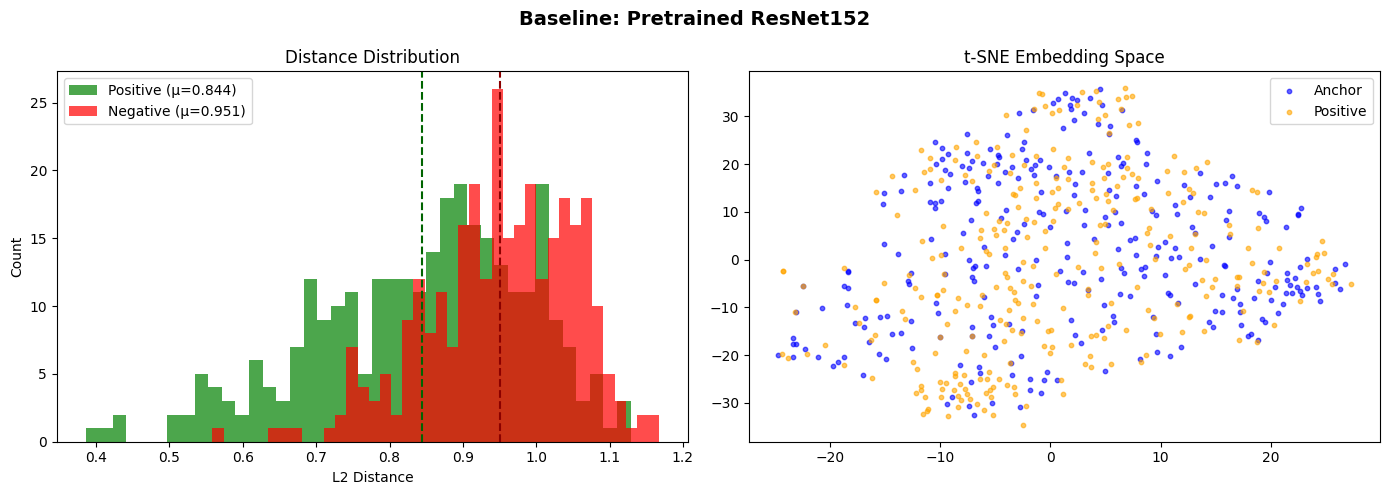

In [19]:
all_results = {}  # 汇总所有实验结果

# ══════════════════════════════════════════════════════════════════════════════
# Experiment 1: Baseline（预训练特征，无 Triplet 训练）
# 目的：确立 before fine-tuning 的 AUC/MAP@K 基线
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("Experiment 1: Pretrained ResNet152 Baseline (no fine-tuning)")
print("="*60)

baseline_cfg = deepcopy(cfg)
baseline_cfg.backbone = "resnet152"
baseline_cfg.use_grad_checkpoint = False  # baseline 不需要

baseline_model = build_model(baseline_cfg).to(device)
# 不训练，直接评估 ImageNet 预训练特征的检索能力

metrics_baseline, embs_a_base, embs_p_base = full_eval(
    baseline_model, anchor_loader, positive_loader, baseline_cfg, "Baseline (no finetune)"
)
all_results['Baseline (Pretrained)'] = metrics_baseline

plot_evaluation(embs_a_base, embs_p_base, title="Baseline: Pretrained ResNet152",
                save_path=os.path.join(cfg.save_dir, 'eval_baseline.png'))


Experiment 2: Fine-tuned ResNet152 + Triplet (Batch Hard)

Training resnet152 | AMP=True | GradCkpt=False
Effective batch = 64 × 1 = 64
Epochs: 1 → 20


Epoch 01/20 | train=0.2122 | val=0.2146 | lr=5.00e-05 | 12s
  ✓ Best saved (val=0.2146)


Epoch 02/20 | train=0.1535 | val=0.1640 | lr=1.00e-04 | 10s
  ✓ Best saved (val=0.1640)


Epoch 03/20 | train=0.1146 | val=0.1546 | lr=1.00e-04 | 11s
  ✓ Best saved (val=0.1546)


Epoch 04/20 | train=0.0926 | val=0.1503 | lr=9.92e-05 | 10s
  ✓ Best saved (val=0.1503)


...

Epoch 06/20 | train=0.0566 | val=0.1688 | lr=9.34e-05 | 10s


Epoch 07/20 | train=0.0409 | val=0.1722 | lr=8.84e-05 | 10s


Epoch 08/20 | train=0.0272 | val=0.1854 | lr=8.23e-05 | 11s


Epoch 09/20 | train=0.0228 | val=0.1886 | lr=7.52e-05 | 11s
  Early stopping at epoch 9

[Eval] Fine-tuned ResNet152


  AUC       : 0.8317
  NDCG@10   : 0.2743
  MAP@1     : 0.1733
  MAP@5     : 0.2338
  MAP@10    : 0.2398
  Eval time : 1.4s


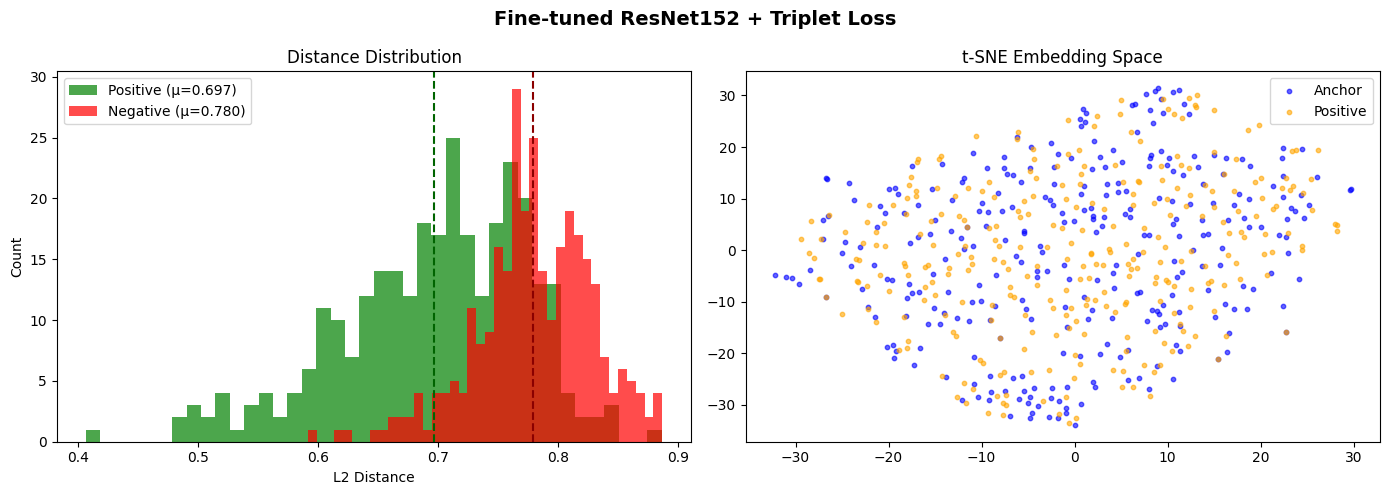

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Experiment 2: Fine-tuned ResNet152 (Triplet Loss + Batch Hard Mining)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("Experiment 2: Fine-tuned ResNet152 + Triplet (Batch Hard)")
print("="*60)

finetune_cfg = deepcopy(cfg)
finetune_cfg.backbone = "resnet152"

model_ft   = build_model(finetune_cfg).to(device)
criterion  = TripletLoss(finetune_cfg.triplet_margin,
                          finetune_cfg.distance_metric,
                          finetune_cfg.mining)
optimizer  = torch.optim.AdamW(model_ft.parameters(),
                                lr=finetune_cfg.lr,
                                weight_decay=finetune_cfg.weight_decay)
scheduler  = WarmupCosineScheduler(optimizer, finetune_cfg.warmup_epochs, finetune_cfg.epochs)
trainer_ft = Trainer(model_ft, criterion, optimizer, scheduler, finetune_cfg,
                     checkpoint_every=1)

# 断点续训：如果 latest checkpoint 存在则自动恢复，否则从头训练
resume_path_ft = os.path.join(finetune_cfg.save_dir, "ckpt_resnet152_latest.pt")
history_ft = trainer_ft.fit(train_loader, val_loader, resume_path=resume_path_ft)

# 加载最优权重评估（加 map_location 防止 GPU/CPU 设备不匹配）
model_ft.load_state_dict(torch.load(
    os.path.join(finetune_cfg.save_dir, "best_resnet152.pt"),
    map_location=device, weights_only=True
))
metrics_ft, embs_a_ft, embs_p_ft = full_eval(
    model_ft, anchor_loader, positive_loader, finetune_cfg, "Fine-tuned ResNet152"
)
all_results['Fine-tuned ResNet152'] = metrics_ft

plot_evaluation(embs_a_ft, embs_p_ft, title="Fine-tuned ResNet152 + Triplet Loss",
                save_path=os.path.join(cfg.save_dir, 'eval_finetuned.png'))


Experiment 3: CLIP ViT-B/32 + LoRA Fine-tuning
LoRA injected into 24 layers
Trainable params: 294,912 / 87,750,912  (0.34%)

Training clip | AMP=True | GradCkpt=False
Effective batch = 64 × 1 = 64
Epochs: 1 → 20


Epoch 01/20 | train=0.1836 | val=0.2231 | lr=2.50e-05 | 5s
  ✓ Best saved (val=0.2231)


Epoch 02/20 | train=0.1634 | val=0.1863 | lr=5.00e-05 | 4s
  ✓ Best saved (val=0.1863)


Epoch 03/20 | train=0.1350 | val=0.1786 | lr=5.00e-05 | 4s
  ✓ Best saved (val=0.1786)


Epoch 04/20 | train=0.1150 | val=0.1611 | lr=4.96e-05 | 4s
  ✓ Best saved (val=0.1611)


...

Epoch 10/20 | train=0.0616 | val=0.1387 | lr=3.39e-05 | 4s


Epoch 11/20 | train=0.0599 | val=0.1363 | lr=2.98e-05 | 4s


Epoch 12/20 | train=0.0553 | val=0.1502 | lr=2.55e-05 | 4s


Epoch 13/20 | train=0.0526 | val=0.1389 | lr=2.12e-05 | 4s
  Early stopping at epoch 13

[Eval] CLIP + LoRA


  AUC       : 0.9513
  NDCG@10   : 0.4917
  MAP@1     : 0.2933
  MAP@5     : 0.4123
  MAP@10    : 0.4248
  Eval time : 1.3s


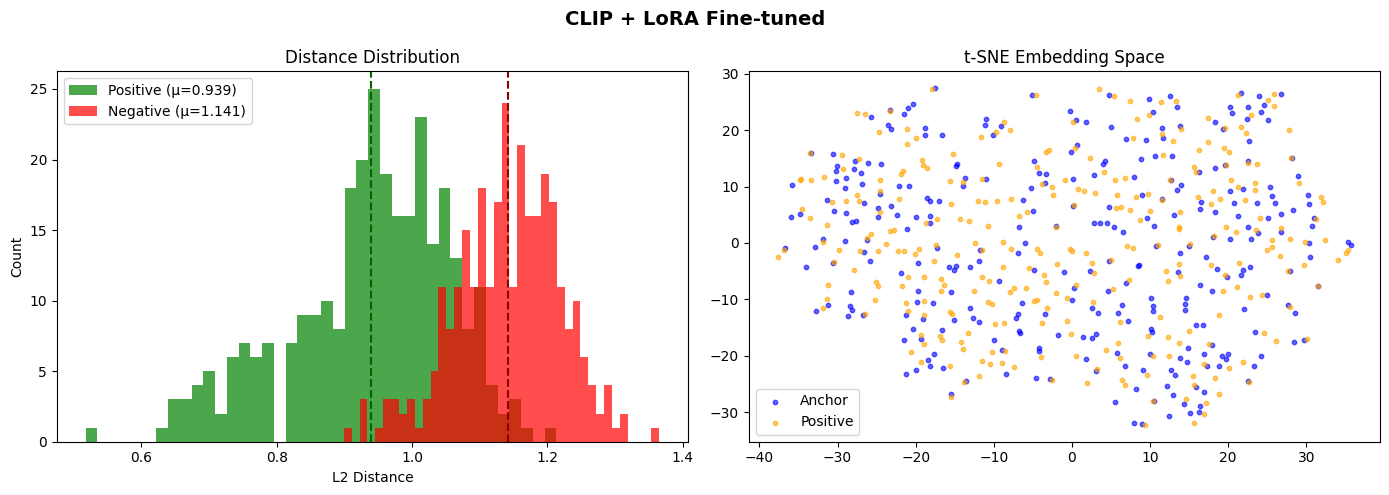

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Experiment 3: CLIP + LoRA（需要安装 transformers + peft）
# ══════════════════════════════════════════════════════════════════════════════
if CLIP_AVAILABLE:
    print("\n" + "="*60)
    print("Experiment 3: CLIP ViT-B/32 + LoRA Fine-tuning")
    print("="*60)

    clip_cfg = deepcopy(cfg)
    clip_cfg.backbone = "clip"
    clip_cfg.lr = 5e-5  # CLIP 学习率比 ResNet 略低，保护预训练知识

    # CLIP 输入归一化（不同于 ImageNet）
    CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
    CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]
    clip_transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(CLIP_MEAN, CLIP_STD),
    ])

    # 重建使用 CLIP 归一化的 DataLoaders
    clip_train_ds = TripletDataset(df_train, cfg.data_root, clip_transform)
    clip_val_ds   = TripletDataset(df_val,   cfg.data_root, clip_transform)
    clip_train_loader = DataLoader(clip_train_ds, batch_size=cfg.batch_size,
                                    shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
    clip_val_loader   = DataLoader(clip_val_ds,   batch_size=cfg.batch_size,
                                    shuffle=False, num_workers=cfg.num_workers, pin_memory=True)

    clip_anchor_loader   = DataLoader(EmbeddingDataset(anchor_images,   cfg.data_root, clip_transform),
                                       batch_size=64, num_workers=cfg.num_workers, pin_memory=True)
    clip_positive_loader = DataLoader(EmbeddingDataset(positive_images, cfg.data_root, clip_transform),
                                       batch_size=64, num_workers=cfg.num_workers, pin_memory=True)

    model_clip = build_model(clip_cfg).to(device)
    opt_clip   = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model_clip.parameters()),
        lr=clip_cfg.lr, weight_decay=clip_cfg.weight_decay
    )
    sch_clip     = WarmupCosineScheduler(opt_clip, clip_cfg.warmup_epochs, clip_cfg.epochs)
    clip_criterion = TripletLoss(clip_cfg.triplet_margin, clip_cfg.distance_metric, clip_cfg.mining)
    trainer_clip = Trainer(model_clip, clip_criterion, opt_clip, sch_clip, clip_cfg,
                           checkpoint_every=1)

    # 断点续训
    resume_path_clip = os.path.join(clip_cfg.save_dir, "ckpt_clip_latest.pt")
    history_clip = trainer_clip.fit(clip_train_loader, clip_val_loader,
                                     resume_path=resume_path_clip)

    # 加载最优权重评估（加 map_location 防止设备不匹配）
    model_clip.load_state_dict(torch.load(
        os.path.join(clip_cfg.save_dir, "best_clip.pt"),
        map_location=device, weights_only=True
    ))
    metrics_clip, embs_a_clip, embs_p_clip = full_eval(
        model_clip, clip_anchor_loader, clip_positive_loader, clip_cfg, "CLIP + LoRA"
    )
    all_results['CLIP + LoRA'] = metrics_clip

    plot_evaluation(embs_a_clip, embs_p_clip, title="CLIP + LoRA Fine-tuned",
                    save_path=os.path.join(cfg.save_dir, 'eval_clip_lora.png'))
else:
    print("CLIP not available. Install transformers + peft to run Experiment 3.")

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# FAISS 速度 Benchmark
# ══════════════════════════════════════════════════════════════════════════════
if FAISS_AVAILABLE and 'embs_a_ft' in dir():
    print("\nFAISS Retrieval Benchmark")
    faiss_results = benchmark_retrieval(
        embs_a_ft, embs_p_ft,
        k=10, nlist=cfg.faiss_nlist, nprobe=cfg.faiss_nprobe
    )
    all_results['FAISS Speedup'] = faiss_results


RESULTS SUMMARY
                          AUC   MAP@1   MAP@5  MAP@10  NDCG@10
Baseline (Pretrained)  0.7255  0.1300  0.1652  0.1723   0.1977
Fine-tuned ResNet152   0.8317  0.1733  0.2338  0.2398   0.2743
CLIP + LoRA            0.9513  0.2933  0.4123  0.4248   0.4917

Triplet Fine-tune → AUC: 0.7255 → 0.8317 (+10.6 pts)


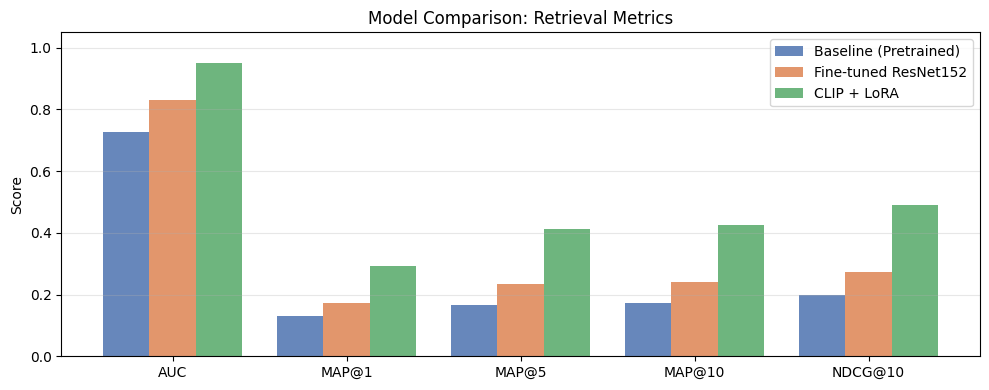

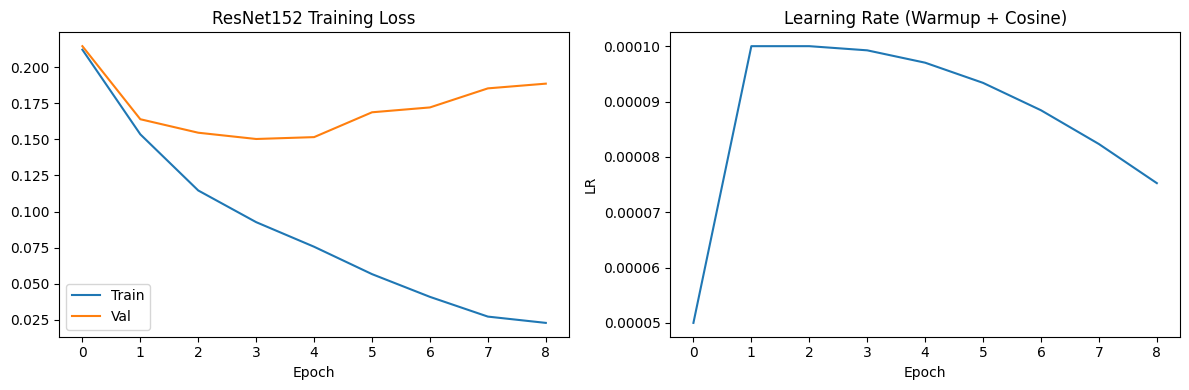


All outputs saved to: /root/autodl-tmp/tll-metric-learning/checkpoints


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# 最终结果汇总表
# ══════════════════════════════════════════════════════════════════════════════
if all_results:
    model_results = {k: v for k, v in all_results.items() if k != 'FAISS Speedup'}
    df_results = pd.DataFrame(model_results).T

    cols_order = ['AUC', 'MAP@1', 'MAP@5', 'MAP@10', 'NDCG@10']
    cols_present = [c for c in cols_order if c in df_results.columns]
    df_results = df_results[cols_present].astype(float)

    print("\n" + "="*60)
    print("RESULTS SUMMARY")
    print("="*60)
    print(df_results.round(4).to_string())
    print()

    # 计算 fine-tune 带来的提升
    if 'Baseline (Pretrained)' in df_results.index and 'Fine-tuned ResNet152' in df_results.index:
        base_auc = df_results.loc['Baseline (Pretrained)', 'AUC']
        ft_auc   = df_results.loc['Fine-tuned ResNet152',  'AUC']
        print(f"Triplet Fine-tune → AUC: {base_auc:.4f} → {ft_auc:.4f} (+{(ft_auc-base_auc)*100:.1f} pts)")

    # 可视化对比
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(cols_present))
    width = 0.8 / len(df_results)
    colors = ['#4C72B0', '#DD8452', '#55A868']

    for i, (idx, row) in enumerate(df_results.iterrows()):
        ax.bar(x + i * width, row[cols_present].values,
               width, label=idx, color=colors[i % len(colors)], alpha=0.85)

    ax.set_xticks(x + width * (len(df_results) - 1) / 2)
    ax.set_xticklabels(cols_present)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title('Model Comparison: Retrieval Metrics')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.save_dir, 'results_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # 训练曲线
    if 'history_ft' in dir():
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(history_ft['train_loss'], label='Train')
        axes[0].plot(history_ft['val_loss'],   label='Val')
        axes[0].set_title('ResNet152 Training Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].legend()

        axes[1].plot(history_ft['lr'])
        axes[1].set_title('Learning Rate (Warmup + Cosine)')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('LR')

        plt.tight_layout()
        plt.savefig(os.path.join(cfg.save_dir, 'training_curves.png'), dpi=150, bbox_inches='tight')
        plt.show()

print("\nAll outputs saved to:", cfg.save_dir)

## Section 8 — Test Set Inference & Submission

**任务对齐**：测试集是 Re-ranking 任务，每个 query 对应 20 个候选，输出每个候选的相似度分数。
与 val 评估（开放式 nearest neighbor）不同，这里是 20 选 1，难度更低但更贴近实际比赛目标。

提交格式：`left, c0, c1, ..., c19` — 值为 cosine similarity，评测系统取最高分的候选作为预测。

In [24]:
def generate_submission(model: nn.Module, cfg: Config, transform,
                        save_path: str = None) -> pd.DataFrame:
    """
    生成测试集提交文件。

    流程：
    1. 对 2000 个 query（test 2/left）提取 embedding
    2. 对所有候选（test 2/right）提取 embedding，按 query 分组为 (N, 20, D)
    3. cosine similarity = 内积（embedding 已 L2 归一化）
    4. 输出 sample-submission.csv 格式：left + c0..c19 的相似度分数
    """
    df_test = pd.read_csv(os.path.join(cfg.data_root, cfg.test_csv))
    cand_cols = [f'c{i}' for i in range(20)]
    n_q = len(df_test)
    print(f"Queries: {n_q}  |  Candidates per query: 20  |  Total: {n_q * 20}")

    # ── 1. Query embeddings（test 2/left）────────────────────────────────────
    query_items  = [(row['left'], 'left') for _, row in df_test.iterrows()]
    query_loader = DataLoader(
        EmbeddingDataset(query_items, cfg.data_root, transform, split=cfg.test_split),
        batch_size=cfg.batch_size, num_workers=cfg.num_workers, pin_memory=True
    )
    query_embs = extract_embeddings(model, query_loader, use_amp=cfg.use_amp)  # (N, D)

    # ── 2. Candidate embeddings（test 2/right）───────────────────────────────
    # 20 个候选 flatten 成一个列表，extract 后 reshape 回 (N, 20, D)
    cand_names   = df_test[cand_cols].values.flatten().tolist()
    cand_items   = [(name, 'right') for name in cand_names]
    cand_loader  = DataLoader(
        EmbeddingDataset(cand_items, cfg.data_root, transform, split=cfg.test_split),
        batch_size=cfg.batch_size, num_workers=cfg.num_workers, pin_memory=True
    )
    cand_embs = extract_embeddings(model, cand_loader, use_amp=cfg.use_amp)  # (N*20, D)
    cand_embs = cand_embs.reshape(n_q, 20, -1)                               # (N, 20, D)

    # ── 3. Cosine similarity（已 L2 归一化，内积 = cosine）───────────────────
    scores = (query_embs[:, None, :] * cand_embs).sum(axis=-1)  # (N, 20)

    # ── 4. 构建提交 DataFrame ────────────────────────────────────────────────
    sub = df_test[['left']].copy()
    for i, col in enumerate(cand_cols):
        sub[col] = scores[:, i]

    if save_path is None:
        save_path = os.path.join(cfg.save_dir, f"submission_{cfg.backbone}.csv")
    sub.to_csv(save_path, index=False)

    print(f"Saved   : {save_path}")
    print(f"Score   : mean={scores.mean():.4f}  std={scores.std():.4f}")
    print(f"Top-1 predicted candidate distribution:\n"
          f"  {np.bincount(scores.argmax(axis=1), minlength=20)}")
    return sub


# ── 对每个训练好的模型生成提交文件 ────────────────────────────────────────────
# ResNet152 fine-tuned
if 'model_ft' in dir():
    model_ft.load_state_dict(torch.load(
        os.path.join(finetune_cfg.save_dir, "best_resnet152.pt"),
        map_location=device, weights_only=True
    ))
    sub_ft = generate_submission(model_ft, finetune_cfg, val_transform)

# CLIP + LoRA
if CLIP_AVAILABLE and 'model_clip' in dir():
    model_clip.load_state_dict(torch.load(
        os.path.join(clip_cfg.save_dir, "best_clip.pt"),
        map_location=device, weights_only=True
    ))
    sub_clip = generate_submission(model_clip, clip_cfg, clip_transform)

print("\nDone. Upload the CSV to the competition leaderboard.")

Queries: 2000  |  Candidates per query: 20  |  Total: 40000


Saved   : /root/autodl-tmp/tll-metric-learning/checkpoints/submission_resnet152.csv
Score   : mean=0.6964  std=0.0413
Top-1 predicted candidate distribution:
  [ 83 109  90 106  98 103  92  95  98  94  98 100  92  97 116 114  93 113
 100 109]
Queries: 2000  |  Candidates per query: 20  |  Total: 40000


Saved   : /root/autodl-tmp/tll-metric-learning/checkpoints/submission_clip.csv
Score   : mean=0.3501  std=0.0951
Top-1 predicted candidate distribution:
  [105 113  84 110 116 113  97  93  92 114  88  93  85  98 103  96  88 103
 110  99]

Done. Upload the CSV to the competition leaderboard.


## Section 9 — Robustness: Multi-seed / Multi-split Experiments

**为什么必须做重复实验？**  
单次 split 的指标很容易被数据划分偶然性放大。算法岗更关注：结论是否稳定、方差多大、模型提升是否具有统计上的重复性。  

本节新增三类能力：
- **Multi-seed**：固定实验配置，改变训练随机种子
- **Multi-split**：改变 train/val 随机切分，观察结论稳定性
- **自动汇总**：输出每次 run 的明细，以及 `mean ± std` 汇总表


In [13]:
import json
# ── Advanced Experiment Helpers ─────────────────────────────────────────────
ADVANCED_RESULTS_DIR = os.path.join(cfg.save_dir, "advanced_results")
os.makedirs(ADVANCED_RESULTS_DIR, exist_ok=True)


def set_global_seed(seed: int):
    """统一设置 Python / NumPy / PyTorch 随机种子。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class TripletDatasetV2(Dataset):
    """
    可控负样本策略的 Triplet Dataset，用于消融实验。

    negative_sampling:
    - 'mixed'     : left/right 两侧混合采样（默认，最稳妥）
    - 'left_only' : 只从 left 侧采样负样本
    - 'right_only': 只从 right 侧采样负样本
    """

    def __init__(self, df: pd.DataFrame, data_root: str,
                 transform=None, negative_sampling: str = 'mixed'):
        self.df = df.reset_index(drop=True)
        self.data_root = data_root
        self.transform = transform
        self.negative_sampling = negative_sampling
        self.n = len(df)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        anchor = load_image(row['left'], 'left', self.data_root)
        positive = load_image(row['right'], 'right', self.data_root)

        neg_idx = (idx + random.randint(1, self.n - 1)) % self.n
        if self.negative_sampling == 'mixed':
            neg_side = random.choice(['left', 'right'])
        elif self.negative_sampling == 'left_only':
            neg_side = 'left'
        elif self.negative_sampling == 'right_only':
            neg_side = 'right'
        else:
            raise ValueError(f"Unknown negative_sampling={self.negative_sampling}")

        negative = load_image(self.df.iloc[neg_idx][neg_side], neg_side, self.data_root)

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative


CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD = [0.26862954, 0.26130258, 0.27577711]


def build_transforms_for_backbone(backbone: str, run_cfg: Config):
    if backbone == 'clip':
        train_tf = T.Compose([
            T.Resize((run_cfg.img_size, run_cfg.img_size)),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.03),
            T.ToTensor(),
            T.Normalize(CLIP_MEAN, CLIP_STD),
        ])
        eval_tf = T.Compose([
            T.Resize((run_cfg.img_size, run_cfg.img_size)),
            T.ToTensor(),
            T.Normalize(CLIP_MEAN, CLIP_STD),
        ])
    else:
        train_tf = T.Compose([
            T.Resize((run_cfg.img_size, run_cfg.img_size)),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
            T.RandomGrayscale(p=0.05),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
        eval_tf = T.Compose([
            T.Resize((run_cfg.img_size, run_cfg.img_size)),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return train_tf, eval_tf


def make_train_val_split(df_all: pd.DataFrame, val_split: float = 0.15,
                         seed: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """随机打乱后切分，避免顺序切分带来的偶然偏差。"""
    idx = np.arange(len(df_all))
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)

    n_val = int(len(df_all) * val_split)
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]

    df_train_run = df_all.iloc[train_idx].reset_index(drop=True)
    df_val_run = df_all.iloc[val_idx].reset_index(drop=True)
    return df_train_run, df_val_run


def build_eval_loaders(df_subset: pd.DataFrame, run_cfg: Config, split: str = 'train'):
    _, eval_tf = build_transforms_for_backbone(run_cfg.backbone, run_cfg)
    anchor_items = [(r['left'], 'left') for _, r in df_subset.iterrows()]
    positive_items = [(r['right'], 'right') for _, r in df_subset.iterrows()]

    anchor_loader = DataLoader(
        EmbeddingDataset(anchor_items, run_cfg.data_root, eval_tf, split=split),
        batch_size=64, num_workers=run_cfg.num_workers, pin_memory=True
    )
    positive_loader = DataLoader(
        EmbeddingDataset(positive_items, run_cfg.data_root, eval_tf, split=split),
        batch_size=64, num_workers=run_cfg.num_workers, pin_memory=True
    )
    return anchor_items, positive_items, anchor_loader, positive_loader


def build_loaders_from_split(df_train_run: pd.DataFrame, df_val_run: pd.DataFrame,
                             run_cfg: Config):
    train_tf, eval_tf = build_transforms_for_backbone(run_cfg.backbone, run_cfg)
    negative_sampling = getattr(run_cfg, 'negative_sampling', 'mixed')

    train_ds = TripletDatasetV2(
        df_train_run, run_cfg.data_root, train_tf,
        negative_sampling=negative_sampling,
    )
    val_ds = TripletDatasetV2(
        df_val_run, run_cfg.data_root, eval_tf,
        negative_sampling=negative_sampling,
    )

    train_loader = DataLoader(
        train_ds, batch_size=run_cfg.batch_size, shuffle=True,
        num_workers=run_cfg.num_workers, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=run_cfg.batch_size, shuffle=False,
        num_workers=run_cfg.num_workers, pin_memory=True
    )

    anchor_items, positive_items, anchor_loader, positive_loader = build_eval_loaders(
        df_val_run, run_cfg, split='train'
    )

    return {
        'train_loader': train_loader,
        'val_loader': val_loader,
        'anchor_items': anchor_items,
        'positive_items': positive_items,
        'anchor_loader': anchor_loader,
        'positive_loader': positive_loader,
        'eval_transform': eval_tf,
    }


def slugify(text: str) -> str:
    text = text.lower().replace(' ', '_').replace('/', '_').replace('+', 'plus')
    return ''.join(ch for ch in text if ch.isalnum() or ch in ('_', '-'))


@torch.no_grad()
def compute_rank_metrics(query_embs: np.ndarray, gallery_embs: np.ndarray,
                         k_values: List[int] = [1, 5, 10]):
    """
    计算更贴近检索任务的 rank-based 指标。

    返回：
    - Hit@K / Recall@K
    - MRR
    - 每个 query 的 ground-truth rank
    - 排序索引矩阵
    """
    q_norm = query_embs / (np.linalg.norm(query_embs, axis=1, keepdims=True) + 1e-8)
    g_norm = gallery_embs / (np.linalg.norm(gallery_embs, axis=1, keepdims=True) + 1e-8)
    sim_matrix = q_norm @ g_norm.T
    sorted_idx = np.argsort(sim_matrix, axis=1)[:, ::-1]

    gt = np.arange(len(query_embs))[:, None]
    ranks = (sorted_idx == gt).argmax(axis=1) + 1

    metrics = {'MRR': float(np.mean(1.0 / ranks))}
    for k in k_values:
        hit = float(np.mean(ranks <= k))
        metrics[f'Hit@{k}'] = hit
        metrics[f'Recall@{k}'] = hit  # 单正样本场景下，Hit@K = Recall@K

    return metrics, ranks, sim_matrix, sorted_idx


def full_eval_plus(model: nn.Module, anchor_loader, positive_loader,
                   run_cfg: Config, label: str = ""):
    """在原 full_eval 基础上补充 rank 指标。"""
    metrics, anchor_embs, positive_embs = full_eval(
        model, anchor_loader, positive_loader, run_cfg, label=label
    )
    rank_metrics, ranks, sim_matrix, sorted_idx = compute_rank_metrics(
        anchor_embs, positive_embs, k_values=run_cfg.eval_k_values
    )
    metrics.update(rank_metrics)

    print(f"  MRR       : {metrics['MRR']:.4f}")
    for k in run_cfg.eval_k_values:
        print(f"  Hit@{k:<2d}    : {metrics[f'Hit@{k}']:.4f}")

    return metrics, anchor_embs, positive_embs, ranks, sim_matrix, sorted_idx


def prepare_run_cfg(base_cfg: Config, experiment_name: str,
                    overrides: Dict = None, seed: int = 42,
                    split_seed: int = 42, root_dir: str = ADVANCED_RESULTS_DIR):
    run_cfg = deepcopy(base_cfg)
    overrides = overrides or {}

    for key, value in overrides.items():
        setattr(run_cfg, key, value)

    if run_cfg.backbone == 'clip' and 'lr' not in overrides:
        run_cfg.lr = 5e-5

    run_cfg.seed = seed
    run_cfg.split_seed = split_seed
    if not hasattr(run_cfg, 'negative_sampling'):
        run_cfg.negative_sampling = overrides.get('negative_sampling', 'mixed')

    run_name = f"{slugify(experiment_name)}__seed{seed}__split{split_seed}"
    run_cfg.save_dir = os.path.join(root_dir, run_name)
    os.makedirs(run_cfg.save_dir, exist_ok=True)
    return run_cfg


def train_and_evaluate_once(df_all: pd.DataFrame, base_cfg: Config,
                            experiment_name: str, overrides: Dict = None,
                            seed: int = 42, split_seed: int = 42,
                            return_artifacts: bool = False):
    """单次完整实验：随机切分 → 训练 → 评估 → 结果落盘。"""
    run_cfg = prepare_run_cfg(base_cfg, experiment_name, overrides, seed, split_seed)
    set_global_seed(seed)

    wandb.init(
        project="tll-metric-learning",
        name=f"{experiment_name}__seed{seed}__split{split_seed}",
        config={k: getattr(run_cfg, k) for k in vars(run_cfg) if not k.startswith("_")},
        reinit=True,
    )
    df_train_run, df_val_run = make_train_val_split(df_all, run_cfg.val_split, split_seed)
    loaders = build_loaders_from_split(df_train_run, df_val_run, run_cfg)

    model = build_model(run_cfg).to(device)
    criterion = TripletLoss(run_cfg.triplet_margin, run_cfg.distance_metric, run_cfg.mining)

    trainable_params = filter(lambda p: p.requires_grad, model.parameters()) if run_cfg.backbone == 'clip' \
        else model.parameters()

    optimizer = torch.optim.AdamW(
        trainable_params, lr=run_cfg.lr, weight_decay=run_cfg.weight_decay
    )
    scheduler = WarmupCosineScheduler(optimizer, run_cfg.warmup_epochs, run_cfg.epochs)
    # checkpoint_every > epochs → 禁用 rolling checkpoint（批量实验不需要 resume）
    trainer = Trainer(model, criterion, optimizer, scheduler, run_cfg,
                      checkpoint_every=run_cfg.epochs + 1)
    history = trainer.fit(loaders['train_loader'], loaders['val_loader'], resume_path=None)

    best_weight_path = os.path.join(run_cfg.save_dir, f"best_{run_cfg.backbone}.pt")
    model.load_state_dict(torch.load(best_weight_path, map_location=device, weights_only=True))

    metrics, anchor_embs, positive_embs, ranks, sim_matrix, sorted_idx = full_eval_plus(
        model,
        loaders['anchor_loader'],
        loaders['positive_loader'],
        run_cfg,
        label=experiment_name,
    )

    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(run_cfg.save_dir, 'history.csv'), index=False)

    result_row = {
        'experiment': experiment_name,
        'backbone': run_cfg.backbone,
        'seed': seed,
        'split_seed': split_seed,
        'negative_sampling': getattr(run_cfg, 'negative_sampling', 'mixed'),
        'save_dir': run_cfg.save_dir,
        **{k: getattr(run_cfg, k) for k in [
            'embedding_dim', 'lr', 'triplet_margin', 'mining',
            'lora_r', 'lora_alpha'
        ] if hasattr(run_cfg, k)},
        **metrics,
    }

    with open(os.path.join(run_cfg.save_dir, 'config.json'), 'w') as f:
        json.dump(result_row, f, indent=2)

    if not return_artifacts:
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        # 清理完整 checkpoint，只保留 best 纯权重文件（供 Phase B 加载）
        for _tag in ['latest', 'best']:
            _ckpt = os.path.join(run_cfg.save_dir, f'ckpt_{run_cfg.backbone}_{_tag}.pt')
            if os.path.exists(_ckpt):
                os.remove(_ckpt)
        wandb.log(metrics)
        wandb.finish()
        return result_row

    artifacts = {
        'run_cfg': run_cfg,
        'model': model,
        'df_train': df_train_run,
        'df_val': df_val_run,
        'loaders': loaders,
        'anchor_embs': anchor_embs,
        'positive_embs': positive_embs,
        'ranks': ranks,
        'sim_matrix': sim_matrix,
        'sorted_idx': sorted_idx,
    }
    wandb.log(metrics)
    wandb.finish()
    return result_row, artifacts


def run_repeated_experiments(df_all: pd.DataFrame, base_cfg: Config,
                             experiment_specs: List[Dict],
                             seeds: List[int], split_seeds: List[int],
                             save_name: str = 'repeated_results') -> pd.DataFrame:
    """批量运行多个实验配置，并导出每次 run 的原始结果。"""
    assert len(seeds) == len(split_seeds), "seeds 和 split_seeds 长度必须一致"
    rows = []

    for spec in experiment_specs:
        print("\n" + "#" * 80)
        print(f"[Repeated Runs] {spec['name']}")
        print("#" * 80)
        overrides = spec.get('overrides', {})

        for seed, split_seed in zip(seeds, split_seeds):
            print(f"\n--- seed={seed} | split_seed={split_seed} ---")
            row = train_and_evaluate_once(
                df_all, base_cfg,
                experiment_name=spec['name'],
                overrides=overrides,
                seed=seed,
                split_seed=split_seed,
                return_artifacts=False,
            )
            rows.append(row)
            log_experiment_result(
                spec['name'], spec.get('overrides', {}), row,
                seed=seed, split_seed=split_seed,
            )

    df_runs = pd.DataFrame(rows)
    csv_path = os.path.join(ADVANCED_RESULTS_DIR, f'{save_name}.csv')
    df_runs.to_csv(csv_path, index=False)
    print(f"\nSaved repeated-run details to: {csv_path}")
    return df_runs


def summarize_experiment_results(df_runs: pd.DataFrame,
                                 metric_cols: List[str] = None) -> pd.DataFrame:
    if metric_cols is None:
        metric_cols = [
            'AUC', 'MAP@1', 'MAP@5', 'MAP@10', 'NDCG@10',
            'MRR', 'Hit@1', 'Hit@5', 'Hit@10'
        ]
    metric_cols = [c for c in metric_cols if c in df_runs.columns]

    summary = df_runs.groupby('experiment')[metric_cols].agg(['mean', 'std'])
    summary.columns = [f'{metric}_{stat}' for metric, stat in summary.columns]
    summary = summary.reset_index()
    return summary


def format_summary_for_display(df_summary: pd.DataFrame,
                               metrics: List[str] = None) -> pd.DataFrame:
    metrics = metrics or ['AUC', 'MAP@1', 'MAP@5', 'MAP@10', 'NDCG@10', 'MRR']
    rows = []
    for _, row in df_summary.iterrows():
        formatted = {'experiment': row['experiment']}
        for metric in metrics:
            mean_col = f'{metric}_mean'
            std_col = f'{metric}_std'
            if mean_col in row and std_col in row:
                formatted[metric] = f"{row[mean_col]:.4f} ± {row[std_col]:.4f}"
        rows.append(formatted)
    return pd.DataFrame(rows)


# ── Persistent Experiment Log ────────────────────────────────────────────────
EXPERIMENT_LOG_PATH = os.path.join(cfg.save_dir, 'experiment_log.json')


def log_experiment_result(name: str, config_overrides: dict, metrics: dict,
                          seed: int = None, split_seed: int = None) -> None:
    """Append one run to the persistent JSON log (safe across kernel restarts)."""
    entry = {
        'timestamp': time.strftime('%Y-%m-%dT%H:%M:%S'),
        'name': name,
        'seed': seed,
        'split_seed': split_seed,
        'save_dir': metrics.get('save_dir', ''),  # 直接记录路径，Phase B 无需重建
        'config': config_overrides,
        'metrics': {
            k: round(float(v), 6) if isinstance(v, (float, np.floating)) else v
            for k, v in metrics.items()
            if k not in ('experiment', 'backbone', 'save_dir', 'seed',
                         'split_seed', 'negative_sampling', 'name')
        },
    }
    log = []
    if os.path.exists(EXPERIMENT_LOG_PATH):
        with open(EXPERIMENT_LOG_PATH) as _f:
            try:
                log = json.load(_f)
            except json.JSONDecodeError:
                log = []
    log.append(entry)
    with open(EXPERIMENT_LOG_PATH, 'w') as _f:
        json.dump(log, _f, indent=2, ensure_ascii=False)
    auc = metrics.get('AUC', float('nan'))
    map10 = metrics.get('MAP@10', float('nan'))
    try:
        auc_str = f"{float(auc):.4f}"
    except Exception:
        auc_str = str(auc)
    try:
        map10_str = f"{float(map10):.4f}"
    except Exception:
        map10_str = str(map10)
    print(f"[log] {entry['timestamp']} | {name} | seed={seed} | "
          f"AUC={auc_str}  MAP@10={map10_str}")


def load_experiment_log() -> pd.DataFrame:
    """Load full persistent experiment log as a flat DataFrame."""
    if not os.path.exists(EXPERIMENT_LOG_PATH):
        print(f"No log found at {EXPERIMENT_LOG_PATH}")
        return pd.DataFrame()
    with open(EXPERIMENT_LOG_PATH) as _f:
        log = json.load(_f)
    rows = []
    for entry in log:
        row = {
            'timestamp': entry['timestamp'],
            'name': entry['name'],
            'seed': entry.get('seed'),
            'split_seed': entry.get('split_seed'),
            'save_dir': entry.get('save_dir', ''),
        }
        row.update(entry.get('metrics', {}))
        row.update({f'cfg_{k}': v for k, v in entry.get('config', {}).items()})
        rows.append(row)
    return pd.DataFrame(rows)


def show_best_models(metric: str = 'MAP@10', top_n: int = 5) -> pd.DataFrame:
    """Print top-N experiments by mean of `metric` from the persistent log."""
    log_df = load_experiment_log()
    if log_df.empty or metric not in log_df.columns:
        print("Log is empty or metric not found — run some experiments first.")
        return pd.DataFrame()
    summary = (
        log_df.groupby('name')[metric]
        .agg(['mean', 'std', 'count'])
        .sort_values('mean', ascending=False)
        .head(top_n)
        .rename(columns={'mean': f'{metric}_mean', 'std': f'{metric}_std', 'count': 'n_runs'})
    )
    display(summary)
    return summary


In [26]:
# ── Robustness Runs: main models across multiple seeds / splits ─────────────
ROBUSTNESS_SEEDS = [42, 52, 62]
ROBUSTNESS_SPLIT_SEEDS = [101, 202, 303]

ROBUSTNESS_SPECS = [
    {
        'name': 'resnet152_triplet_batch_hard',
        'overrides': {
            'backbone': 'resnet152',
            'mining': 'batch_hard',
            'negative_sampling': 'mixed',
        },
    },
]

if CLIP_AVAILABLE:
    ROBUSTNESS_SPECS.append({
        'name': 'clip_lora_qv_r8',
        'overrides': {
            'backbone': 'clip',
            'lr': 5e-5,
            'lora_target_modules': ['q_proj', 'v_proj'],
            'lora_r': 8,
            'lora_alpha': 16,
            'negative_sampling': 'mixed',
        },
    })

robustness_runs = run_repeated_experiments(
    df_all=df_all,
    base_cfg=cfg,
    experiment_specs=ROBUSTNESS_SPECS,
    seeds=ROBUSTNESS_SEEDS,
    split_seeds=ROBUSTNESS_SPLIT_SEEDS,
    save_name='robustness_runs',
)

robustness_summary = summarize_experiment_results(robustness_runs)
robustness_display = format_summary_for_display(robustness_summary)
robustness_summary.to_csv(os.path.join(ADVANCED_RESULTS_DIR, 'robustness_summary.csv'), index=False)
print("\nRobustness Summary")
display(robustness_display)



################################################################################
[Repeated Runs] resnet152_triplet_batch_hard
################################################################################

--- seed=42 | split_seed=101 ---


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



Training resnet152 | AMP=True | GradCkpt=False
Effective batch = 64 × 1 = 64
Epochs: 1 → 20


Epoch 01/20 | train=0.1987 | val=0.2023 | lr=5.00e-05 | 11s
  ✓ Best saved (val=0.2023)


Epoch 02/20 | train=0.1473 | val=0.1652 | lr=1.00e-04 | 11s
  ✓ Best saved (val=0.1652)


...

Epoch 20/20 | train=0.0523 | val=0.1377 | lr=1.37e-06 | 7s

[Eval] clip_lora_qv_r8


  AUC       : 0.9522
  NDCG@10   : 0.5358
  MAP@1     : 0.3733
  MAP@5     : 0.4615
  MAP@10    : 0.4756
  Eval time : 1.2s
  MRR       : 0.4846
  Hit@1     : 0.3733
  Hit@5     : 0.6233
  Hit@10    : 0.7300


AUC,▁
Hit@1,▁
Hit@10,▁
Hit@5,▁
MAP@1,▁
MAP@10,▁
MAP@5,▁
MRR,▁
NDCG@10,▁
Recall@1,▁
+7,...


[log] 2026-05-24T14:48:49 | clip_lora_qv_r8 | seed=62 | AUC=0.9522  MAP@10=0.4756

Saved repeated-run details to: /root/autodl-tmp/tll-metric-learning/checkpoints/advanced_results/robustness_runs.csv

Robustness Summary


,experiment,AUC,MAP@1,MAP@5,MAP@10,NDCG@10,MRR
0,clip_lora_qv_r8,0.9511 ± 0.0014,0.3667 ± 0.0088,0.4611 ± 0.0017,0.4724 ± 0.0035,0.5288 ± 0.0070,0.4829 ± 0.0024
1,resnet152_triplet_batch_hard,0.8019 ± 0.0125,0.1389 ± 0.0117,0.1966 ± 0.0120,0.2055 ± 0.0126,0.2440 ± 0.0142,0.2203 ± 0.0122


## Section 10 — Ablation Studies

**这一节的目标不是追求最高分，而是解释“为什么这个方法有效”。**  
消融实验优先回答三个问题：
- **采样与挖掘策略是否重要？**
- **LoRA 的注入位置和秩是否重要？**
- **Embedding 维度是否影响泛化与检索？**

服务器跑完后，你就能把“模型效果好”升级成“我知道效果为什么好”。


In [ ]:
# ── Ablation Plan ───────────────────────────────────────────────────────────
ABLATION_SEEDS = [42, 52, 62]
ABLATION_SPLIT_SEEDS = [111, 222, 333]

ABLATION_SPECS = [
    {
        'name': 'resnet_batch_hard_mixed_neg',
        'overrides': {
            'backbone': 'resnet152',
            'mining': 'batch_hard',
            'negative_sampling': 'mixed',
        },
    },
    {
        'name': 'resnet_random_mining_mixed_neg',
        'overrides': {
            'backbone': 'resnet152',
            'mining': 'random',
            'negative_sampling': 'mixed',
        },
    },
    {
        'name': 'resnet_batch_hard_left_only_neg',
        'overrides': {
            'backbone': 'resnet152',
            'mining': 'batch_hard',
            'negative_sampling': 'left_only',
        },
    },
]

if CLIP_AVAILABLE:
    ABLATION_SPECS.extend([
        {
            'name': 'clip_lora_qv_r8_dim256',
            'overrides': {
                'backbone': 'clip',
                'lr': 5e-5,
                'lora_target_modules': ['q_proj', 'v_proj'],
                'lora_r': 8,
                'lora_alpha': 16,
                'embedding_dim': 256,
            },
        },
        {
            'name': 'clip_lora_q_only',
            'overrides': {
                'backbone': 'clip',
                'lr': 5e-5,
                'lora_target_modules': ['q_proj'],
                'lora_r': 8,
                'lora_alpha': 16,
                'embedding_dim': 256,
            },
        },
        {
            'name': 'clip_lora_v_only',
            'overrides': {
                'backbone': 'clip',
                'lr': 5e-5,
                'lora_target_modules': ['v_proj'],
                'lora_r': 8,
                'lora_alpha': 16,
                'embedding_dim': 256,
            },
        },
        {
            'name': 'clip_lora_r4',
            'overrides': {
                'backbone': 'clip',
                'lr': 5e-5,
                'lora_target_modules': ['q_proj', 'v_proj'],
                'lora_r': 4,
                'lora_alpha': 8,
                'embedding_dim': 256,
            },
        },
        {
            'name': 'clip_lora_r16',
            'overrides': {
                'backbone': 'clip',
                'lr': 5e-5,
                'lora_target_modules': ['q_proj', 'v_proj'],
                'lora_r': 16,
                'lora_alpha': 32,
                'embedding_dim': 256,
            },
        },
        {
            'name': 'clip_lora_dim128',
            'overrides': {
                'backbone': 'clip',
                'lr': 5e-5,
                'lora_target_modules': ['q_proj', 'v_proj'],
                'lora_r': 8,
                'lora_alpha': 16,
                'embedding_dim': 128,
            },
        },
        {
            'name': 'clip_lora_dim512',
            'overrides': {
                'backbone': 'clip',
                'lr': 5e-5,
                'lora_target_modules': ['q_proj', 'v_proj'],
                'lora_r': 8,
                'lora_alpha': 16,
                'embedding_dim': 512,
            },
        },
        {
            'name': 'clip_lora_qkv_r8',
            'overrides': {
                'backbone': 'clip',
                'lr': 5e-5,
                'lora_target_modules': ['q_proj', 'k_proj', 'v_proj'],
                'lora_r': 8,
                'lora_alpha': 16,
                'embedding_dim': 256,
            },
        },
        {
            'name': 'clip_lora_qv_out_r8',
            'overrides': {
                'backbone': 'clip',
                'lr': 5e-5,
                'lora_target_modules': ['q_proj', 'v_proj', 'out_proj'],
                'lora_r': 8,
                'lora_alpha': 16,
                'embedding_dim': 256,
            },
        },
    ])

ablation_runs = run_repeated_experiments(
    df_all=df_all,
    base_cfg=cfg,
    experiment_specs=ABLATION_SPECS,
    seeds=ABLATION_SEEDS,
    split_seeds=ABLATION_SPLIT_SEEDS,
    save_name='ablation_runs',
)

ablation_summary = summarize_experiment_results(ablation_runs)
ablation_display = format_summary_for_display(ablation_summary)
ablation_summary.to_csv(os.path.join(ADVANCED_RESULTS_DIR, 'ablation_summary.csv'), index=False)
print("\nAblation Summary")
display(ablation_display)



################################################################################
[Repeated Runs] resnet_batch_hard_mixed_neg
################################################################################

--- seed=42 | split_seed=111 ---



Training resnet152 | AMP=True | GradCkpt=False
Effective batch = 64 × 1 = 64
Epochs: 1 → 20


Epoch 01/20 | train=0.2001 | val=0.2005 | lr=5.00e-05 | 11s
  ✓ Best saved (val=0.2005)


Epoch 02/20 | train=0.1475 | val=0.1688 | lr=1.00e-04 | 11s
  ✓ Best saved (val=0.1688)


Epoch 03/20 | train=0.1137 | val=0.1547 | lr=1.00e-04 | 11s
  ✓ Best saved (val=0.1547)


...

Epoch 01/20 | train=0.1808 | val=0.2196 | lr=2.50e-05 | 7s
  ✓ Best saved (val=0.2196)


Epoch 02/20 | train=0.1625 | val=0.1826 | lr=5.00e-05 | 7s
  ✓ Best saved (val=0.1826)


Epoch 03/20 | train=0.1377 | val=0.1726 | lr=5.00e-05 | 7s
  ✓ Best saved (val=0.1726)


Epoch 04/20 | train=0.1171 | val=0.1653 | lr=4.96e-05 | 7s
  ✓ Best saved (val=0.1653)


Train:  93%|█████████▎| 25/27 [00:05<00:00,  6.43it/s]

In [14]:
RESUME_SPECS = [
    {'name': 'clip_lora_qkv_r8', 'overrides': {'backbone': 'clip', 'lr': 5e-5,
        'lora_target_modules': ['q_proj', 'k_proj', 'v_proj'],
        'lora_r': 8, 'lora_alpha': 16, 'embedding_dim': 256}},
    {'name': 'clip_lora_qv_out_r8', 'overrides': {'backbone': 'clip', 'lr': 5e-5,
        'lora_target_modules': ['q_proj', 'v_proj', 'out_proj'],
        'lora_r': 8, 'lora_alpha': 16, 'embedding_dim': 256}},
]

run_repeated_experiments(df_all, cfg, RESUME_SPECS,
                         seeds=[42, 52, 62], split_seeds=[111, 222, 333],
                         save_name='ablation_runs_final')


################################################################################
[Repeated Runs] clip_lora_qkv_r8
################################################################################

--- seed=42 | split_seed=111 ---


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


LoRA injected into 36 layers
Trainable params: 442,368 / 87,898,368  (0.50%)

Training clip | AMP=True | GradCkpt=False
Effective batch = 64 × 1 = 64
Epochs: 1 → 20


Epoch 01/20 | train=0.1808 | val=0.2196 | lr=2.50e-05 | 7s
  ✓ Best saved (val=0.2196)


Epoch 02/20 | train=0.1625 | val=0.1826 | lr=5.00e-05 | 7s
  ✓ Best saved (val=0.1826)


...

Epoch 14/20 | train=0.0534 | val=0.1267 | lr=1.71e-05 | 6s
  Early stopping at epoch 14

[Eval] clip_lora_qv_out_r8


  AUC       : 0.9504
  NDCG@10   : 0.5617
  MAP@1     : 0.4100
  MAP@5     : 0.4949
  MAP@10    : 0.5092
  Eval time : 1.2s
  MRR       : 0.5201
  Hit@1     : 0.4100
  Hit@5     : 0.6233
  Hit@10    : 0.7300


AUC,▁
Hit@1,▁
Hit@10,▁
Hit@5,▁
MAP@1,▁
MAP@10,▁
MAP@5,▁
MRR,▁
NDCG@10,▁
Recall@1,▁
+7,...


[log] 2026-05-24T16:30:24 | clip_lora_qv_out_r8 | seed=62 | AUC=0.9504  MAP@10=0.5092

Saved repeated-run details to: /root/autodl-tmp/tll-metric-learning/checkpoints/advanced_results/ablation_runs_final.csv


,experiment,backbone,seed,split_seed,negative_sampling,save_dir,embedding_dim,lr,triplet_margin,mining,...,MAP@5,MAP@10,eval_time_s,MRR,Hit@1,Recall@1,Hit@5,Recall@5,Hit@10,Recall@10
0,clip_lora_qkv_r8,clip,42,111,mixed,/root/autodl-tmp/tll-metric-learning/checkpoin...,256,0.00005,0.1,batch_hard,...,0.491667,0.506495,1.24,0.515415,0.413333,0.413333,0.640000,0.640000,0.750000,0.750000
1,clip_lora_qkv_r8,clip,52,222,mixed,/root/autodl-tmp/tll-metric-learning/checkpoin...,256,0.00005,0.1,batch_hard,...,0.420833,0.431438,1.13,0.442247,0.316667,0.316667,0.590000,0.590000,0.666667,0.666667
2,clip_lora_qkv_r8,clip,62,333,mixed,/root/autodl-tmp/tll-metric-learning/checkpoin...,256,0.00005,0.1,batch_hard,...,0.488389,0.501001,1.21,0.511440,0.403333,0.403333,0.623333,0.623333,0.723333,0.723333
3,clip_lora_qv_out_r8,clip,42,111,mixed,/root/autodl-tmp/tll-metric-learning/checkpoin...,256,0.00005,0.1,batch_hard,...,0.495444,0.509836,1.25,0.518610,0.410000,0.410000,0.646667,0.646667,0.756667,0.756667
4,clip_lora_qv_out_r8,clip,52,222,mixed,/root/autodl-tmp/tll-metric-learning/checkpoin...,256,0.00005,0.1,batch_hard,...,0.426778,0.441139,1.24,0.451143,0.333333,0.333333,0.573333,0.573333,0.680000,0.680000
5,clip_lora_qv_out_r8,clip,62,333,mixed,/root/autodl-tmp/tll-metric-learning/checkpoin...,256,0.00005,0.1,batch_hard,...,0.494944,0.509171,1.17,0.520121,0.410000,0.410000,0.623333,0.623333,0.730000,0.730000


## Section 11 — Failure Analysis

**算法岗不是只看分数，更看你是否知道模型为什么错。**  
本节会导出：
- 每个 query 的 ground-truth rank
- Top-1 误检样本及其分数
- rank 分布直方图
- query / gt / wrong top-1 的可视化面板

建议你在服务器跑完后，优先看：
1. `rank > 10` 的 hardest failures  
2. CLIP+LoRA 比 ResNet 改善了哪些样本类型  
3. 哪些失败来自语义误判，哪些来自形状/颜色误判


In [ ]:
# ── Failure Analysis Helpers ────────────────────────────────────────────────
FAILURE_ANALYSIS_DIR = os.path.join(ADVANCED_RESULTS_DIR, 'failure_analysis')
os.makedirs(FAILURE_ANALYSIS_DIR, exist_ok=True)


def _first_wrong_prediction(sorted_idx_row: np.ndarray, gt_idx: int) -> int:
    for idx in sorted_idx_row:
        if idx != gt_idx:
            return int(idx)
    return int(sorted_idx_row[0])


def plot_rank_histogram(ranks: np.ndarray, title: str, save_path: str):
    plt.figure(figsize=(8, 4))
    bins = np.arange(1, min(31, ranks.max() + 2)) - 0.5
    plt.hist(ranks, bins=bins, color='#4C72B0', alpha=0.85, edgecolor='white')
    plt.xlabel('Ground-truth Rank')
    plt.ylabel('Count')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_failure_panel(failure_df: pd.DataFrame, run_cfg: Config,
                       title: str, save_path: str,
                       max_cases: int = 8):
    if failure_df.empty:
        print(f"{title}: no failures to plot")
        return

    n_show = min(max_cases, len(failure_df))
    fig, axes = plt.subplots(n_show, 3, figsize=(10, 3.2 * n_show))
    if n_show == 1:
        axes = np.array([axes])

    for ax_row, (_, row) in zip(axes, failure_df.head(n_show).iterrows()):
        query_img = load_image(row['query_name'], 'left', run_cfg.data_root, split='train')
        gt_img = load_image(row['gt_name'], 'right', run_cfg.data_root, split='train')
        wrong_img = load_image(row['top1_wrong_name'], 'right', run_cfg.data_root, split='train')

        ax_row[0].imshow(query_img)
        ax_row[0].set_title(f"Query\n{row['query_name']}")
        ax_row[1].imshow(gt_img)
        ax_row[1].set_title(f"GT rank={int(row['gt_rank'])}\n{row['gt_name']}")
        ax_row[2].imshow(wrong_img)
        ax_row[2].set_title(
            f"Wrong top-1\n{row['top1_wrong_name']}\n"
            f"s={row['top1_wrong_score']:.3f}"
        )

        for ax in ax_row:
            ax.axis('off')

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def analyze_failure_cases(model: nn.Module, df_subset: pd.DataFrame,
                          run_cfg: Config, label: str,
                          max_cases: int = 8):
    anchor_items, positive_items, anchor_loader, positive_loader = build_eval_loaders(
        df_subset, run_cfg, split='train'
    )
    metrics, anchor_embs, positive_embs, ranks, sim_matrix, sorted_idx = full_eval_plus(
        model, anchor_loader, positive_loader, run_cfg, label=label
    )

    rows = []
    for i, rank in enumerate(ranks):
        wrong_idx = _first_wrong_prediction(sorted_idx[i], i)
        rows.append({
            'query_name': anchor_items[i][0],
            'gt_name': positive_items[i][0],
            'gt_rank': int(rank),
            'gt_score': float(sim_matrix[i, i]),
            'top1_pred_name': positive_items[int(sorted_idx[i, 0])][0],
            'top1_pred_score': float(sim_matrix[i, int(sorted_idx[i, 0])]),
            'top1_wrong_name': positive_items[wrong_idx][0],
            'top1_wrong_score': float(sim_matrix[i, wrong_idx]),
        })

    rank_df = pd.DataFrame(rows).sort_values(['gt_rank', 'top1_wrong_score'], ascending=[False, False])
    csv_path = os.path.join(FAILURE_ANALYSIS_DIR, f'{slugify(label)}_failures.csv')
    rank_df['failure_type'] = rank_df.apply(classify_failure_type, axis=1)
    rank_df.to_csv(csv_path, index=False)

    hist_path = os.path.join(FAILURE_ANALYSIS_DIR, f'{slugify(label)}_rank_hist.png')
    plot_rank_histogram(ranks, f'{label}: Ground-truth Rank Distribution', hist_path)
    breakdown_path = os.path.join(FAILURE_ANALYSIS_DIR, f'{slugify(label)}_type_breakdown.png')
    plot_failure_type_breakdown(rank_df, label, breakdown_path)

    failure_only = rank_df[rank_df['gt_rank'] > 1].copy()
    panel_path = os.path.join(FAILURE_ANALYSIS_DIR, f'{slugify(label)}_failure_panel.png')
    plot_failure_panel(
        failure_only,
        run_cfg=run_cfg,
        title=f'{label}: Hard Failure Cases',
        save_path=panel_path,
        max_cases=max_cases,
    )

    print(f"Saved failure CSV  : {csv_path}")
    print(f"Saved rank hist    : {hist_path}")
    print(f"Saved failure panel: {panel_path}")
    return failure_only, rank_df, metrics


def classify_failure_type(row: pd.Series) -> str:
    """
    Heuristic failure taxonomy based on similarity scores and rank.

    Categories:
    - near_miss    : gt_rank ≤ 3, score gap small  → model almost correct
    - hard_positive: gt_score low (<0.4)            → model fails to pull anchor/positive together
    - strong_fp    : wrong_score high (>0.8), gt_score much lower → strong false positive
    - complete_miss: gt_rank > 10                  → model totally lost
    - margin_fail  : default mid-range failures
    """
    rank = int(row['gt_rank'])
    gt_score = float(row['gt_score'])
    wrong_score = float(row['top1_wrong_score'])
    gap = wrong_score - gt_score

    if rank == 1:
        return 'correct'
    if rank > 10:
        return 'complete_miss'
    if gt_score < 0.40:
        return 'hard_positive'
    if wrong_score > 0.80 and gap > 0.15:
        return 'strong_fp'
    if rank <= 3 and gap < 0.05:
        return 'near_miss'
    return 'margin_fail'


def plot_failure_type_breakdown(rank_df: pd.DataFrame, label: str, save_path: str):
    """Bar chart of failure type distribution."""
    if 'failure_type' not in rank_df.columns:
        rank_df = rank_df.copy()
        rank_df['failure_type'] = rank_df.apply(classify_failure_type, axis=1)
    counts = rank_df['failure_type'].value_counts()
    order = ['correct', 'near_miss', 'margin_fail', 'hard_positive', 'strong_fp', 'complete_miss']
    counts = counts.reindex([t for t in order if t in counts.index], fill_value=0)
    colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336', '#9C27B0']
    plt.figure(figsize=(8, 4))
    bars = plt.bar(counts.index, counts.values,
                   color=colors[:len(counts)], edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=10)
    plt.title(f'{label}: Failure Type Breakdown')
    plt.ylabel('Count')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def compare_model_failures(report_a: dict, report_b: dict,
                           label_a: str = 'ModelA', label_b: str = 'ModelB') -> pd.DataFrame:
    """
    Given two failure reports (from analyze_failure_cases),
    return cases where one model succeeds and the other fails.
    Useful for understanding what CLIP+LoRA fixes over ResNet.
    """
    df_a = report_a['ranks'].set_index('query_name')['gt_rank']
    df_b = report_b['ranks'].set_index('query_name')['gt_rank']
    merged = pd.DataFrame({label_a: df_a, label_b: df_b}).dropna()
    merged[f'{label_a}_correct'] = merged[label_a] == 1
    merged[f'{label_b}_correct'] = merged[label_b] == 1
    a_wins = merged[merged[f'{label_a}_correct'] & ~merged[f'{label_b}_correct']]
    b_wins = merged[~merged[f'{label_a}_correct'] & merged[f'{label_b}_correct']]
    both_fail = merged[~merged[f'{label_a}_correct'] & ~merged[f'{label_b}_correct']]
    print(f"{label_a} wins (A correct, B wrong): {len(a_wins)}")
    print(f"{label_b} wins (B correct, A wrong): {len(b_wins)}")
    print(f"Both fail: {len(both_fail)}")
    return merged


In [ ]:
# ── Failure Analysis on current best models ─────────────────────────────────
failure_reports = {}

if 'model_ft' in dir() and 'finetune_cfg' in dir():
    model_ft.load_state_dict(torch.load(
        os.path.join(finetune_cfg.save_dir, 'best_resnet152.pt'),
        map_location=device, weights_only=True
    ))
    resnet_failures, resnet_ranks, resnet_metrics = analyze_failure_cases(
        model_ft, df_val, finetune_cfg, label='resnet152_val', max_cases=8
    )
    failure_reports['resnet152'] = {
        'failures': resnet_failures,
        'ranks': resnet_ranks,
        'metrics': resnet_metrics,
    }

if CLIP_AVAILABLE and 'model_clip' in dir() and 'clip_cfg' in dir():
    model_clip.load_state_dict(torch.load(
        os.path.join(clip_cfg.save_dir, 'best_clip.pt'),
        map_location=device, weights_only=True
    ))
    clip_failures, clip_ranks, clip_metrics = analyze_failure_cases(
        model_clip, df_val, clip_cfg, label='clip_lora_val', max_cases=8
    )
    failure_reports['clip_lora'] = {
        'failures': clip_failures,
        'ranks': clip_ranks,
        'metrics': clip_metrics,
    }

print("\nFailure analysis finished. Reports saved to:", FAILURE_ANALYSIS_DIR)


## Section 12 — Phase B: Inference Engine & Model Selection

**目标：** 从 Phase A 实验日志中自动选出最优模型，封装 model-agnostic 端到端推理接口，做 latency benchmark。

| 步骤 | 内容 |
|------|------|
| 12a | 从实验日志自动选出最优模型（按 MAP@10 排名） |
| 12b | `InferenceEngine`：checkpoint → embedding → FAISS → top-K |
| 12c | 端到端 latency benchmark（p50 / p95 / batch throughput） |

**设计原则：** 推理接口与具体模型解耦——Phase A 结果出来后只需传入最优 checkpoint 路径即可。


In [15]:
# ── 12a: Select best model from persistent experiment log ────────────────────
print("=" * 60)
print("Phase B — Best Model Selection")
print("=" * 60)

log_df = load_experiment_log()

if log_df.empty:
    print("No experiment log yet — run Phase A experiments first.")
    BEST_MODEL_NAME = None
else:
    print(f"Total runs logged: {len(log_df)}")
    print()
    show_best_models(metric='MAP@10', top_n=10)

    best_summary = (
        log_df.groupby('name')['MAP@10']
        .agg(['mean', 'std', 'count'])
        .sort_values('mean', ascending=False)
    )
    BEST_MODEL_NAME = best_summary.index[0]
    print(f"\nAuto-selected best model : {BEST_MODEL_NAME}")
    print(f"  MAP@10 mean = {best_summary.loc[BEST_MODEL_NAME, 'mean']:.4f} "
          f"\u00b1 {best_summary.loc[BEST_MODEL_NAME, 'std']:.4f} "
          f"(n={int(best_summary.loc[BEST_MODEL_NAME, 'count'])})")

    best_runs = (
        log_df[log_df['name'] == BEST_MODEL_NAME]
        .sort_values('MAP@10', ascending=False)
    )
    metric_cols = [c for c in ['name', 'seed', 'split_seed', 'MAP@10', 'AUC', 'MRR']
                   if c in best_runs.columns]
    display(best_runs[metric_cols].head(5))


Phase B — Best Model Selection
Total runs logged: 48



,MAP@10_mean,MAP@10_std,n_runs
name,,,
clip_lora_r16,0.508575,0.024777,3
clip_lora_qv_out_r8,0.486715,0.035305,6
clip_lora_dim512,0.484927,0.031483,3
clip_lora_qkv_r8,0.479645,0.037421,6
clip_lora_qv_r8_dim256,0.478009,0.005744,3
clip_lora_v_only,0.472854,0.001005,3
clip_lora_qv_r8,0.472424,0.003548,3
clip_lora_r4,0.464905,0.014020,3
clip_lora_q_only,0.455046,0.009156,3



Auto-selected best model : clip_lora_r16
  MAP@10 mean = 0.5086 ± 0.0248 (n=3)


,name,seed,split_seed,MAP@10,AUC,MRR
29,clip_lora_r16,62,333,0.534619,0.951578,0.542697
27,clip_lora_r16,42,111,0.505811,0.947611,0.515160
28,clip_lora_r16,52,222,0.485296,0.929400,0.494997


In [16]:
# ── 12b: InferenceEngine — model-agnostic end-to-end retrieval ───────────────
class InferenceEngine:
    """
    End-to-end retrieval engine: load checkpoint → embed → FAISS → top-K.
    Model-agnostic: works for resnet152, clip, or any backbone in build_model().
    """

    def __init__(self, backbone: str, checkpoint_path: str, run_cfg: Config,
                 device: str = None):
        self.backbone = backbone
        self.checkpoint_path = checkpoint_path
        self.run_cfg = run_cfg
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None
        self.faiss_index = None
        self.gallery_embs = None
        self.gallery_names = None
        _, self.eval_tf = build_transforms_for_backbone(backbone, run_cfg)

    def load_model(self) -> None:
        self.model = build_model(self.run_cfg).to(self.device)
        self.model.load_state_dict(
            torch.load(self.checkpoint_path, map_location=self.device, weights_only=True)
        )
        self.model.eval()
        print(f"[Engine] Loaded {self.backbone} from {self.checkpoint_path}")

    def build_gallery(self, df_gallery: pd.DataFrame,
                       split: str = 'train', side: str = 'right') -> None:
        """Extract gallery embeddings and build FAISS index."""
        t0 = time.time()
        items = [(r[side], side) for _, r in df_gallery.iterrows()]
        loader = DataLoader(
            EmbeddingDataset(items, self.run_cfg.data_root, self.eval_tf, split=split),
            batch_size=128, num_workers=self.run_cfg.num_workers, pin_memory=True
        )
        self.gallery_embs = extract_embeddings(self.model, loader)
        self.gallery_names = [r[side] for _, r in df_gallery.iterrows()]
        t_emb = time.time() - t0

        t1 = time.time()
        if FAISS_AVAILABLE:
            self.faiss_index = build_faiss_index(
                self.gallery_embs, self.run_cfg.faiss_nlist, use_gpu=True
            )
        t_idx = time.time() - t1
        print(f"[Engine] Gallery: {len(self.gallery_names)} items | "
              f"embed={t_emb:.1f}s | faiss_index={t_idx:.2f}s")

    @torch.no_grad()
    def query(self, query_imgs: list, top_k: int = 10) -> Tuple[np.ndarray, np.ndarray]:
        """
        Args:
            query_imgs: list of PIL Images
        Returns:
            (scores, indices) each shape (N, top_k)
        """
        tensors = torch.stack([self.eval_tf(img) for img in query_imgs]).to(self.device)
        with autocast('cuda', enabled=('cuda' in str(self.device))):
            q_embs = self.model(tensors).cpu().float().numpy()

        if self.faiss_index is not None:
            faiss.normalize_L2(q_embs)
            scores, indices = self.faiss_index.search(q_embs.astype(np.float32), top_k)
        else:
            g = self.gallery_embs / (np.linalg.norm(self.gallery_embs, axis=1, keepdims=True) + 1e-8)
            q = q_embs / (np.linalg.norm(q_embs, axis=1, keepdims=True) + 1e-8)
            sim = q @ g.T
            indices = np.argsort(sim, axis=1)[:, ::-1][:, :top_k]
            scores = np.take_along_axis(sim, indices, axis=1)
        return scores, indices

    def latency_benchmark(self, df_query: pd.DataFrame, n_queries: int = 100,
                          top_k: int = 10, split: str = 'train') -> dict:
        """Measure per-query and batch latency (ms)."""
        import time as _t
        items = [(r['left'], 'left') for _, r in df_query.head(n_queries).iterrows()]
        imgs = [load_image(n, s, self.run_cfg.data_root, split=split) for n, s in items]

        _ = self.query(imgs[:4], top_k=top_k)  # warm-up

        single_ms = []
        for img in imgs[:min(50, len(imgs))]:
            t0 = _t.perf_counter()
            self.query([img], top_k=top_k)
            single_ms.append((_t.perf_counter() - t0) * 1000)

        t0 = _t.perf_counter()
        self.query(imgs, top_k=top_k)
        batch_ms = (_t.perf_counter() - t0) * 1000

        result = {
            'backbone': self.backbone,
            'n_gallery': len(self.gallery_names) if self.gallery_names else 0,
            'n_queries_bench': n_queries,
            'single_p50_ms': float(np.percentile(single_ms, 50)),
            'single_p95_ms': float(np.percentile(single_ms, 95)),
            'batch_total_ms': float(batch_ms),
            'batch_per_query_ms': float(batch_ms / len(imgs)),
        }
        print(f"\n[Latency] {self.backbone}")
        print(f"  Single-query p50 : {result['single_p50_ms']:.1f} ms")
        print(f"  Single-query p95 : {result['single_p95_ms']:.1f} ms")
        print(f"  Batch ({len(imgs)}q) total : {result['batch_total_ms']:.1f} ms  "
              f"({result['batch_per_query_ms']:.2f} ms/q)")
        return result


In [18]:
class LoRALayer(nn.Module):
    def __init__(self, in_features, out_features, r=8, alpha=16, dropout=0.0):
        super().__init__()
        r = int(r)  # fix
        self.r = r
        self.scaling = alpha / r
        self.lora_A = nn.Parameter(torch.empty(r, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, r))
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

    def forward(self, x):
        return (self.drop(x) @ self.lora_A.T @ self.lora_B.T) * self.scaling

In [27]:
import numpy as np

def _clean_override(v):
    try:
        if np.isnan(v):
            return None
    except (TypeError, ValueError):
        pass
    if isinstance(v, np.bool_):   return bool(v)
    if isinstance(v, np.integer): return int(v)
    if isinstance(v, np.floating):
        fv = float(v)
        return int(fv) if fv == int(fv) else fv
    return v

def prepare_run_cfg(base_cfg, experiment_name, overrides=None, seed=42,
                    split_seed=42, root_dir=ADVANCED_RESULTS_DIR):
    run_cfg = deepcopy(base_cfg)
    overrides = overrides or {}

    for key, value in overrides.items():
        clean_val = _clean_override(value)
        if clean_val is not None:
            setattr(run_cfg, key, clean_val)

    if run_cfg.backbone == 'clip' and 'lr' not in overrides:
        run_cfg.lr = 5e-5

    run_cfg.seed = seed
    run_cfg.split_seed = split_seed
    if not hasattr(run_cfg, 'negative_sampling'):
        run_cfg.negative_sampling = overrides.get('negative_sampling', 'mixed')

    run_name = f"{slugify(experiment_name)}__seed{seed}__split{split_seed}"
    run_cfg.save_dir = os.path.join(root_dir, run_name)
    os.makedirs(run_cfg.save_dir, exist_ok=True)
    return run_cfg

In [28]:
# ── 12c: Run benchmark on best model ─────────────────────────────────────────
latency_results = {}

if BEST_MODEL_NAME is not None and not log_df.empty:
    best_runs_df = (
        log_df[log_df['name'] == BEST_MODEL_NAME]
        .sort_values('MAP@10', ascending=False)
    )
    best_run = best_runs_df.iloc[0]

    # Reconstruct run config from logged overrides
    best_overrides = {k[4:]: v for k, v in best_run.items() if k.startswith('cfg_')}
    best_run_cfg = prepare_run_cfg(
        cfg, BEST_MODEL_NAME, best_overrides,
        seed=int(best_run.get('seed', 42)),
        split_seed=int(best_run.get('split_seed', 42)),
    )

    backbone = best_run_cfg.backbone

    # 优先从日志中直接读取 save_dir，避免 slugify 重建路径与实际不符
    logged_save_dir = best_run.get('save_dir', '')
    if logged_save_dir and os.path.isdir(logged_save_dir):
        ckpt_path = os.path.join(logged_save_dir, f'best_{backbone}.pt')
    else:
        ckpt_path = os.path.join(best_run_cfg.save_dir, f'best_{backbone}.pt')
        print(f'[Warning] save_dir not in log, using reconstructed path: {ckpt_path}')

    if os.path.exists(ckpt_path):
        engine = InferenceEngine(backbone, ckpt_path, best_run_cfg)
        engine.load_model()
        engine.build_gallery(df_val, split='train')
        bench = engine.latency_benchmark(df_val, n_queries=100, top_k=10)
        latency_results[BEST_MODEL_NAME] = bench

        bench_path = os.path.join(ADVANCED_RESULTS_DIR, 'latency_benchmark.json')
        with open(bench_path, 'w') as f:
            json.dump(latency_results, f, indent=2)
        print(f"\nBenchmark saved to: {bench_path}")

        # Copy best checkpoint to a canonical location for easy reference
        best_ckpt_canonical = os.path.join(cfg.save_dir, f'BEST_{backbone}_{BEST_MODEL_NAME}.pt')
        import shutil
        shutil.copy2(ckpt_path, best_ckpt_canonical)
        print(f"Best checkpoint copied to: {best_ckpt_canonical}")
    else:
        print(f"Checkpoint not found: {ckpt_path}")
        print("Run Phase A experiments first, then re-run this cell.")
else:
    print("No experiment log found — run Phase A first.")


LoRA injected into 24 layers
Trainable params: 589,824 / 88,045,824  (0.67%)
[Engine] Loaded clip from /root/autodl-tmp/tll-metric-learning/checkpoints/advanced_results/clip_lora_r16__seed62__split333/best_clip.pt


[Engine] Gallery: 300 items | embed=1.0s | faiss_index=0.00s

[Latency] clip
  Single-query p50 : 9.8 ms
  Single-query p95 : 12.3 ms
  Batch (100q) total : 154.1 ms  (1.54 ms/q)

Benchmark saved to: /root/autodl-tmp/tll-metric-learning/checkpoints/advanced_results/latency_benchmark.json
Best checkpoint copied to: /root/autodl-tmp/tll-metric-learning/checkpoints/BEST_clip_clip_lora_r16.pt


In [32]:
full_log = load_experiment_log()

ablation_names = [
    'resnet_batch_hard_mixed_neg', 'resnet_random_mining_mixed_neg',
    'resnet_batch_hard_left_only_neg', 'clip_lora_qv_r8_dim256',
    'clip_lora_q_only', 'clip_lora_qkv_r8', 'clip_lora_qv_out_r8',
]
ablation_full = full_log[full_log['name'].isin(ablation_names)].rename(columns={'name': 'experiment'})
ablation_summary = summarize_experiment_results(ablation_full)
display(format_summary_for_display(ablation_summary))
ablation_summary.to_csv(os.path.join(ADVANCED_RESULTS_DIR, 'ablation_summary.csv'), index=False)
print(f"Saved to {ADVANCED_RESULTS_DIR}/ablation_summary.csv")

,experiment,AUC,MAP@1,MAP@5,MAP@10,NDCG@10,MRR
0,clip_lora_q_only,0.9341 ± 0.0079,0.3489 ± 0.0117,0.4453 ± 0.0082,0.4550 ± 0.0092,0.5093 ± 0.0102,0.4650 ± 0.0090
1,clip_lora_qkv_r8,0.9429 ± 0.0099,0.3778 ± 0.0475,0.4670 ± 0.0358,0.4796 ± 0.0374,0.5353 ± 0.0367,0.4897 ± 0.0368
2,clip_lora_qv_out_r8,0.9453 ± 0.0102,0.3844 ± 0.0396,0.4724 ± 0.0353,0.4867 ± 0.0353,0.5427 ± 0.0347,0.4966 ± 0.0352
3,clip_lora_qv_r8_dim256,0.9434 ± 0.0044,0.3667 ± 0.0173,0.4642 ± 0.0099,0.4780 ± 0.0057,0.5367 ± 0.0018,0.4880 ± 0.0060
4,resnet_batch_hard_left_only_neg,0.7912 ± 0.0229,0.1367 ± 0.0273,0.1865 ± 0.0227,0.1963 ± 0.0241,0.2325 ± 0.0243,0.2120 ± 0.0252
5,resnet_batch_hard_mixed_neg,0.8004 ± 0.0096,0.1189 ± 0.0051,0.1730 ± 0.0213,0.1856 ± 0.0204,0.2268 ± 0.0259,0.2009 ± 0.0199
6,resnet_random_mining_mixed_neg,0.8429 ± 0.0207,0.1333 ± 0.0058,0.1984 ± 0.0110,0.2103 ± 0.0131,0.2561 ± 0.0167,0.2262 ± 0.0132


Saved to /root/autodl-tmp/tll-metric-learning/checkpoints/advanced_results/ablation_summary.csv
